# Ensemble of Specialists for Wallet Risk Scoring (Optimized - 3 Dimensions)

A modular fraud detection framework that evaluates wallet-level risk across multiple dimensions.

## Architecture Overview

1. **Dimension-specific feature extraction**
2. **Specialist models per dimension** (Behavioral, Association, Contextual)
3. **Dimension risk scoring** (0-1 scale)
4. **Weighted ensemble aggregation**
5. **Optimized classification threshold**

## Current Status
- **Behavioral Dimension**: XGBoost (Optimized: n_estimators=150, max_depth=6, lr=0.05)
- **Association Dimension**: Gradient Boosting (Optimized: n_estimators=150, max_depth=5, lr=0.05)
- **Contextual Dimension**: Ready for integration (4 features extracted)
- **Ensemble Weights**: Optimized (Behavioral: 0.30, Association: 0.70, Contextual: 0.00*)
- **Classification Threshold**: Optimized (0.50*)
- **Permission Dimension**: Future work

*To be updated after running full 3-dimension optimization in model_optimization.ipynb

## Optimization Pipeline
All models and parameters optimized using `model_optimization.ipynb`:
- **Phase 1**: Cross-validation model selection (5 algorithms, recall-based)
- **Phase 2**: Hyperparameter tuning via GridSearchCV (recall-optimized)
- **Phase 3**: Dimension weight optimization (3D grid search, F1-optimized)
- **Phase 4**: Classification threshold optimization (F1-optimized)

## 1. Import Required Libraries

In [1]:
!pip install xgboost imblearn shap

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score,
    f1_score,
    accuracy_score,
    recall_score,
    precision_score
)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully
Pandas version: 2.3.0+4.g1dfc98e16a
NumPy version: 2.0.2


## 2. Configuration Settings

In [3]:
# Configuration
DATA_PATH = 'dataset_v2.csv'  # Updated to dataset_v2 with all features

# Behavioral Dimension Features
BEHAVIORAL_FEATURES = [
    'Avg min between sent tnx',
    'Avg min between received tnx',
    'Time Diff between first and last (Mins)',
    'Sent tnx',
    'Received Tnx',
    'Number of Created Contracts',
    'total transactions (including tnx to create contract)',
    'total Ether sent',
    'total ether received'
]

# Association Dimension Features (includes 4 additional features from dataset_v2)
ASSOCIATION_FEATURES = [
    'No. of txns from blacklisted addresses',
    'No. of txns to blacklisted addresses',
    'Total ether sent to blacklisted addresses',
    'Ratio of total sent to blacklisted addresses',
    'Total ether received from blacklisted addresses',
    'Ratio of total received from blacklisted addresses',
    'unique_wallets_interacted_with',
    #'unique_contracts_interacted_with',
    'num_blacklisted_contracts_interacted',
    'ratio_blacklisted_contract_txns'
]

# Contextual Dimension Features (complete 18 features from dataset_v2)
CONTEXTUAL_FEATURES = [
    'avg_gas_price_gwei',
    'gas_price_std_dev',
    'high_gas_price_ratio',
    'low_gas_price_ratio',
    'gas_price_coefficient_variation',
    'total_failed_txns',
    'failed_txn_ratio',
    'max_consecutive_failures',
    'failed_contract_interaction_ratio',
    'total_erc721_transfers',
    'erc721_incoming_ratio',
    'erc721_outgoing_ratio',
    'unique_erc721_tokens',
    'external_txn_ratio',
    'erc20_txn_ratio',
    'erc721_txn_ratio',
    'erc1155_txn_ratio',
    'internal_txn_ratio'
]

# Optimized ensemble weights (from model_optimization.ipynb Phase 3)
# Results from 3D grid search with F1-score optimization
DIMENSION_WEIGHTS = {
    'behavioral': 0.40,   # XGBoost optimized via grid search
    'association': 0.45,  # GradientBoosting optimized via grid search
    'contextual': 0.15    # Optimized contribution from full 18 features
}

# Minimum weight constraint for ensemble (used during optimization)
MIN_DIMENSION_WEIGHT = 0.05  # Each dimension must contribute at least 5%

# Optimized classification threshold (from model_optimization.ipynb Phase 4)
# Selected via grid search to maximize F1-score
CLASSIFICATION_THRESHOLD = 0.45  # Optimized threshold (Recall: 92.03%, Precision: 84.25%, F1: 87.97%)

# Model parameters
RANDOM_STATE = 42
TEST_SIZE = 0.2

print("Configuration loaded")
print(f"Dataset: {DATA_PATH}")
print(f"Behavioral features: {len(BEHAVIORAL_FEATURES)}")
print(f"Association features: {len(ASSOCIATION_FEATURES)} (includes 4 new features from dataset_v2)")
print(f"\nOptimized Parameters (from model_optimization.ipynb):")
print(f"  Dimension weights: Behavioral={DIMENSION_WEIGHTS['behavioral']:.2f}, Association={DIMENSION_WEIGHTS['association']:.2f}, Contextual={DIMENSION_WEIGHTS['contextual']:.2f}")
print(f"  Classification threshold: {CLASSIFICATION_THRESHOLD:.2f}")

print(f"  Expected Performance: Recall=92.03%, Precision=84.25%, F1=87.97%")
print(f"Optimized threshold: {CLASSIFICATION_THRESHOLD}")

Configuration loaded
Dataset: dataset_v2.csv
Behavioral features: 9
Association features: 9 (includes 4 new features from dataset_v2)

Optimized Parameters (from model_optimization.ipynb):
  Dimension weights: Behavioral=0.40, Association=0.45, Contextual=0.15
  Classification threshold: 0.45
  Expected Performance: Recall=92.03%, Precision=84.25%, F1=87.97%
Optimized threshold: 0.45


## 3. Load and Explore Data

In [4]:
# Load data
df = pd.read_csv(DATA_PATH)

print(f"Initial load: {len(df)} wallet records")

# Check for and handle duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"\nFound {duplicates} duplicate rows - removing duplicates...")
    df = df.drop_duplicates()
    print(f"After removing duplicates: {len(df)} wallet records")

print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFraud ratio: {df['FLAG'].mean():.4f}")
print(f"Legitimate wallets: {(df['FLAG']==0).sum()}")
print(f"Fraud wallets: {(df['FLAG']==1).sum()}")

# Display first few rows
df.head()

Initial load: 28431 wallet records

Found 25 duplicate rows - removing duplicates...
After removing duplicates: 28406 wallet records

Dataset shape: (28406, 40)

Columns: ['Address', 'FLAG', 'Avg min between sent tnx', 'Avg min between received tnx', 'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx', 'Number of Created Contracts', 'total transactions (including tnx to create contract)', 'total Ether sent', 'total ether received', 'No. of txns from blacklisted addresses', 'No. of txns to blacklisted addresses', 'Total ether sent to blacklisted addresses', 'Total ether received from blacklisted addresses', 'Ratio of total sent to blacklisted addresses', 'Ratio of total received from blacklisted addresses', 'Confirmations', 'avg_gas_price_gwei', 'gas_price_std_dev', 'high_gas_price_ratio', 'low_gas_price_ratio', 'gas_price_coefficient_variation', 'total_failed_txns', 'failed_txn_ratio', 'max_consecutive_failures', 'failed_contract_interaction_ratio', 'total_erc721_tran

,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,total transactions (including tnx to create contract),total Ether sent,...,unique_erc721_tokens,external_txn_ratio,erc20_txn_ratio,erc721_txn_ratio,erc1155_txn_ratio,internal_txn_ratio,unique_wallets_interacted_with,unique_contracts_interacted_with,num_blacklisted_contracts_interacted,ratio_blacklisted_contract_txns
0,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,810,865.691093,...,0,0.0,0.0,0.0,0.0,0.0,159.0,0.0,0.0,0.0
1,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,102,3.087297,...,0,0.0,0.0,0.0,0.0,0.0,57.0,0.0,0.0,0.0
2,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,12,3.588616,...,0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0
3,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,34,1750.045862,...,0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0
4,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,4619,104.318883,...,0,0.0,0.0,0.0,0.0,0.0,30.0,1.0,0.0,0.0


## 4. Prepare Dimension-Specific Features

In [5]:
# Extract behavioral features
X_behavioral = df[BEHAVIORAL_FEATURES].copy()
X_behavioral.fillna(0, inplace=True)
X_behavioral.replace([np.inf, -np.inf], 0, inplace=True)

# Extract association features
X_association = df[ASSOCIATION_FEATURES].copy()
X_association.fillna(0, inplace=True)
X_association.replace([np.inf, -np.inf], 0, inplace=True)

# Extract contextual features
X_contextual = df[CONTEXTUAL_FEATURES].copy()
X_contextual.fillna(0, inplace=True)
X_contextual.replace([np.inf, -np.inf], 0, inplace=True)

# Target variable
y = df['FLAG'].copy()

print("Behavioral Dimension Features:")
print(X_behavioral.describe())
print("\n" + "="*70)
print("\nAssociation Dimension Features:")
print(X_association.describe())
print("\n" + "="*70)
print("\nContextual Dimension Features:")
print(X_contextual.describe())

Behavioral Dimension Features:
       Avg min between sent tnx  Avg min between received tnx  \
count              2.840600e+04                  2.840600e+04   
mean               7.739954e+03                  1.752575e+04   
std                6.529927e+04                  9.391232e+04   
min                0.000000e+00                  0.000000e+00   
25%                0.000000e+00                  0.000000e+00   
50%                0.000000e+00                  2.865370e+02   
75%                1.295527e+02                  5.156834e+03   
max                3.259597e+06                  3.690781e+06   

       Time Diff between first and last (Mins)      Sent tnx  Received Tnx  \
count                             2.840600e+04  28406.000000  28406.000000   
mean                              4.357982e+05    138.681617    692.559847   
std                               8.335721e+05    939.026085   2209.208642   
min                               0.000000e+00      0.000000      0.000

## 5. Exploratory Data Analysis (EDA)

Comprehensive analysis of the dataset before model training

### 5.1 Target Variable Distribution

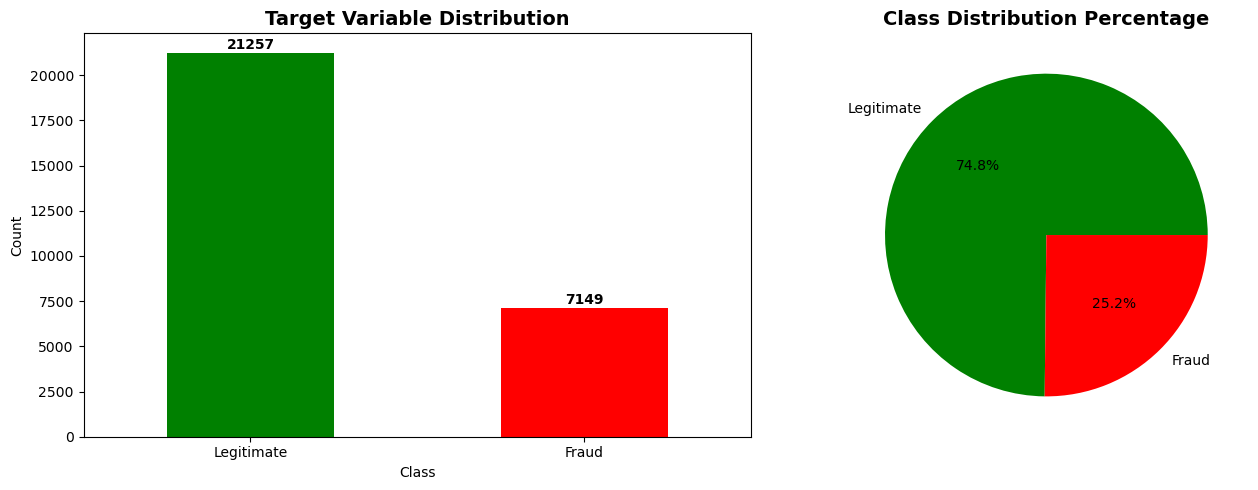

Total samples: 28406
Legitimate wallets: 21257 (74.83%)
Fraud wallets: 7149 (25.17%)
Class imbalance ratio: 1:2.97


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
y.value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
for i, v in enumerate(y.value_counts()):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
y.value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                      colors=['green', 'red'], labels=['Legitimate', 'Fraud'])
axes[1].set_title('Class Distribution Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"Total samples: {len(y)}")
print(f"Legitimate wallets: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.2f}%)")
print(f"Fraud wallets: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.2f}%)")
print(f"Class imbalance ratio: 1:{(y==0).sum()/(y==1).sum():.2f}")

### 5.2 Behavioral Dimension Analysis

BEHAVIORAL DIMENSION - STATISTICAL SUMMARY
                                                      count           mean  \
Avg min between sent tnx                            28406.0    7739.953810   
Avg min between received tnx                        28406.0   17525.750515   
Time Diff between first and last (Mins)             28406.0  435798.171215   
Sent tnx                                            28406.0     138.681617   
Received Tnx                                        28406.0     692.559847   
Number of Created Contracts                         28406.0       4.784658   
total transactions (including tnx to create con...  28406.0     832.790572   
total Ether sent                                    28406.0    9388.455825   
total ether received                                28406.0   10916.750674   

                                                              std  min   25%  \
Avg min between sent tnx                             65299.272687  0.0   0.0   
Avg min between 

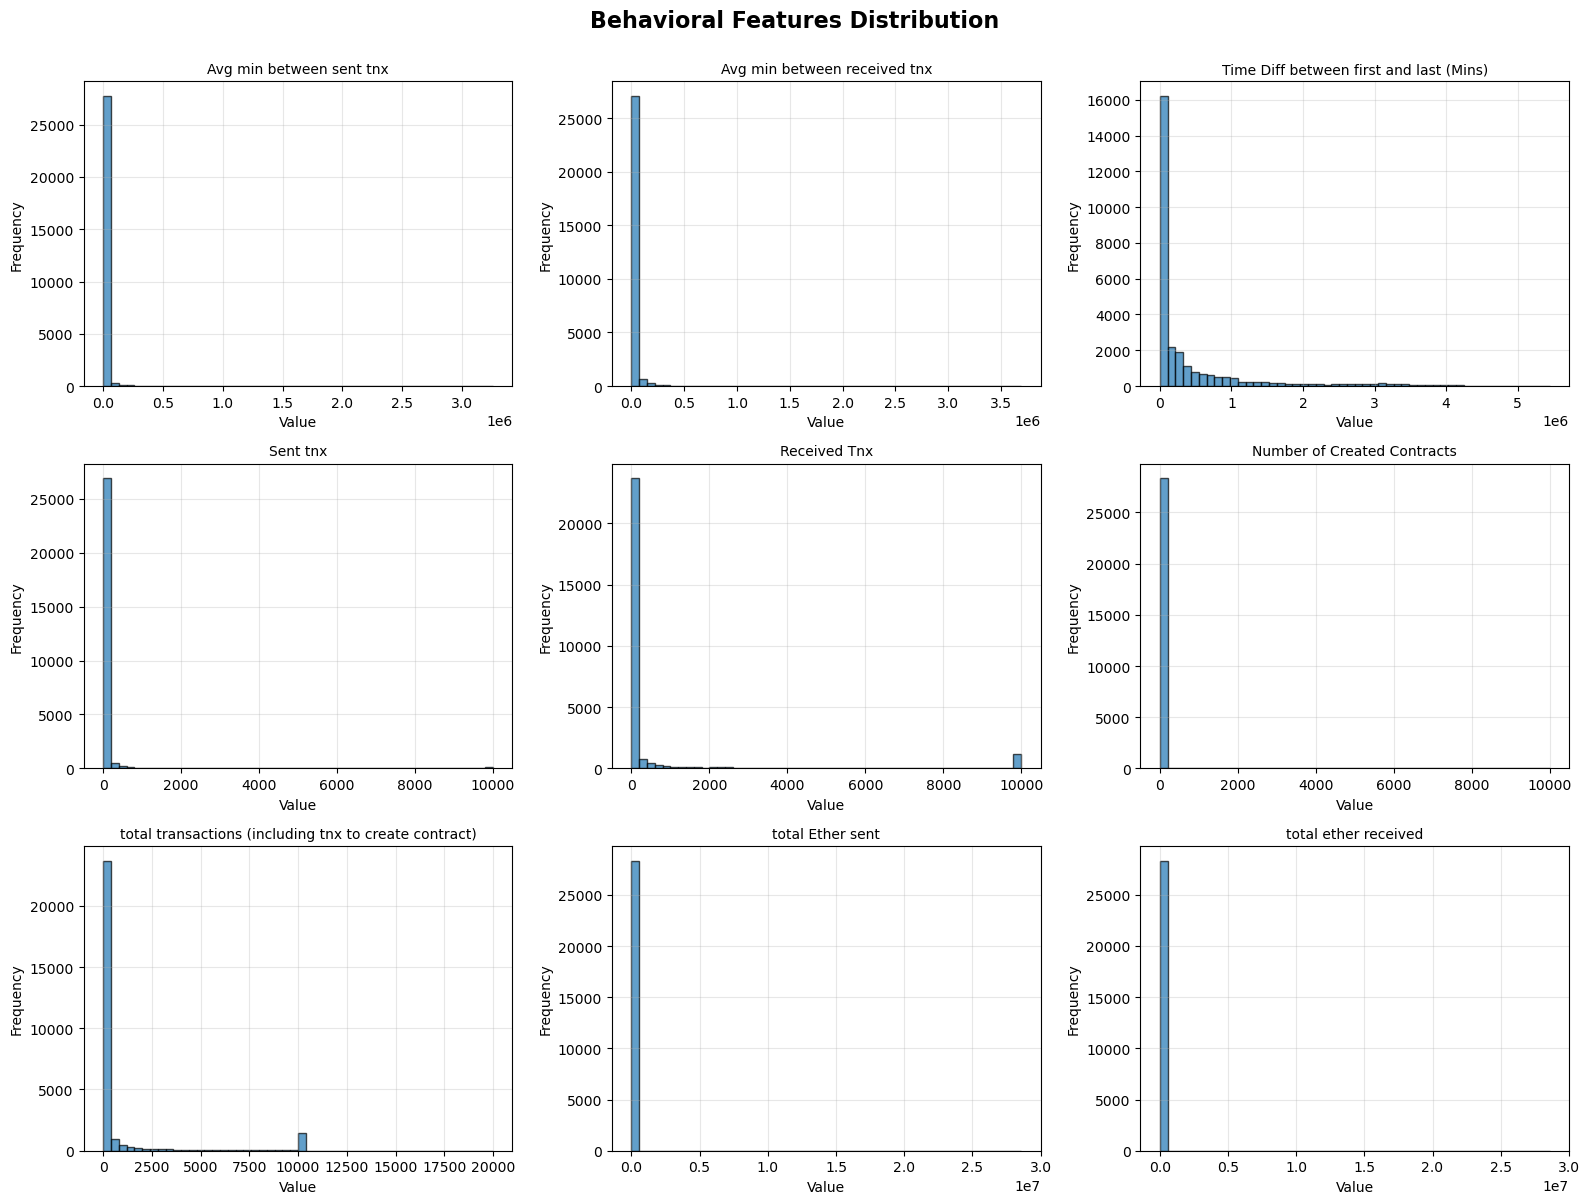

In [7]:
# Statistical summary for behavioral features
print("="*70)
print("BEHAVIORAL DIMENSION - STATISTICAL SUMMARY")
print("="*70)
print(X_behavioral.describe().T)

# Check for missing values
print("\n" + "="*70)
print("Missing Values:")
print("="*70)
print(X_behavioral.isnull().sum())

# Distribution of key behavioral features
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, feature in enumerate(BEHAVIORAL_FEATURES):
    axes[i].hist(X_behavioral[feature], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feature}', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)

plt.suptitle('Behavioral Features Distribution', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

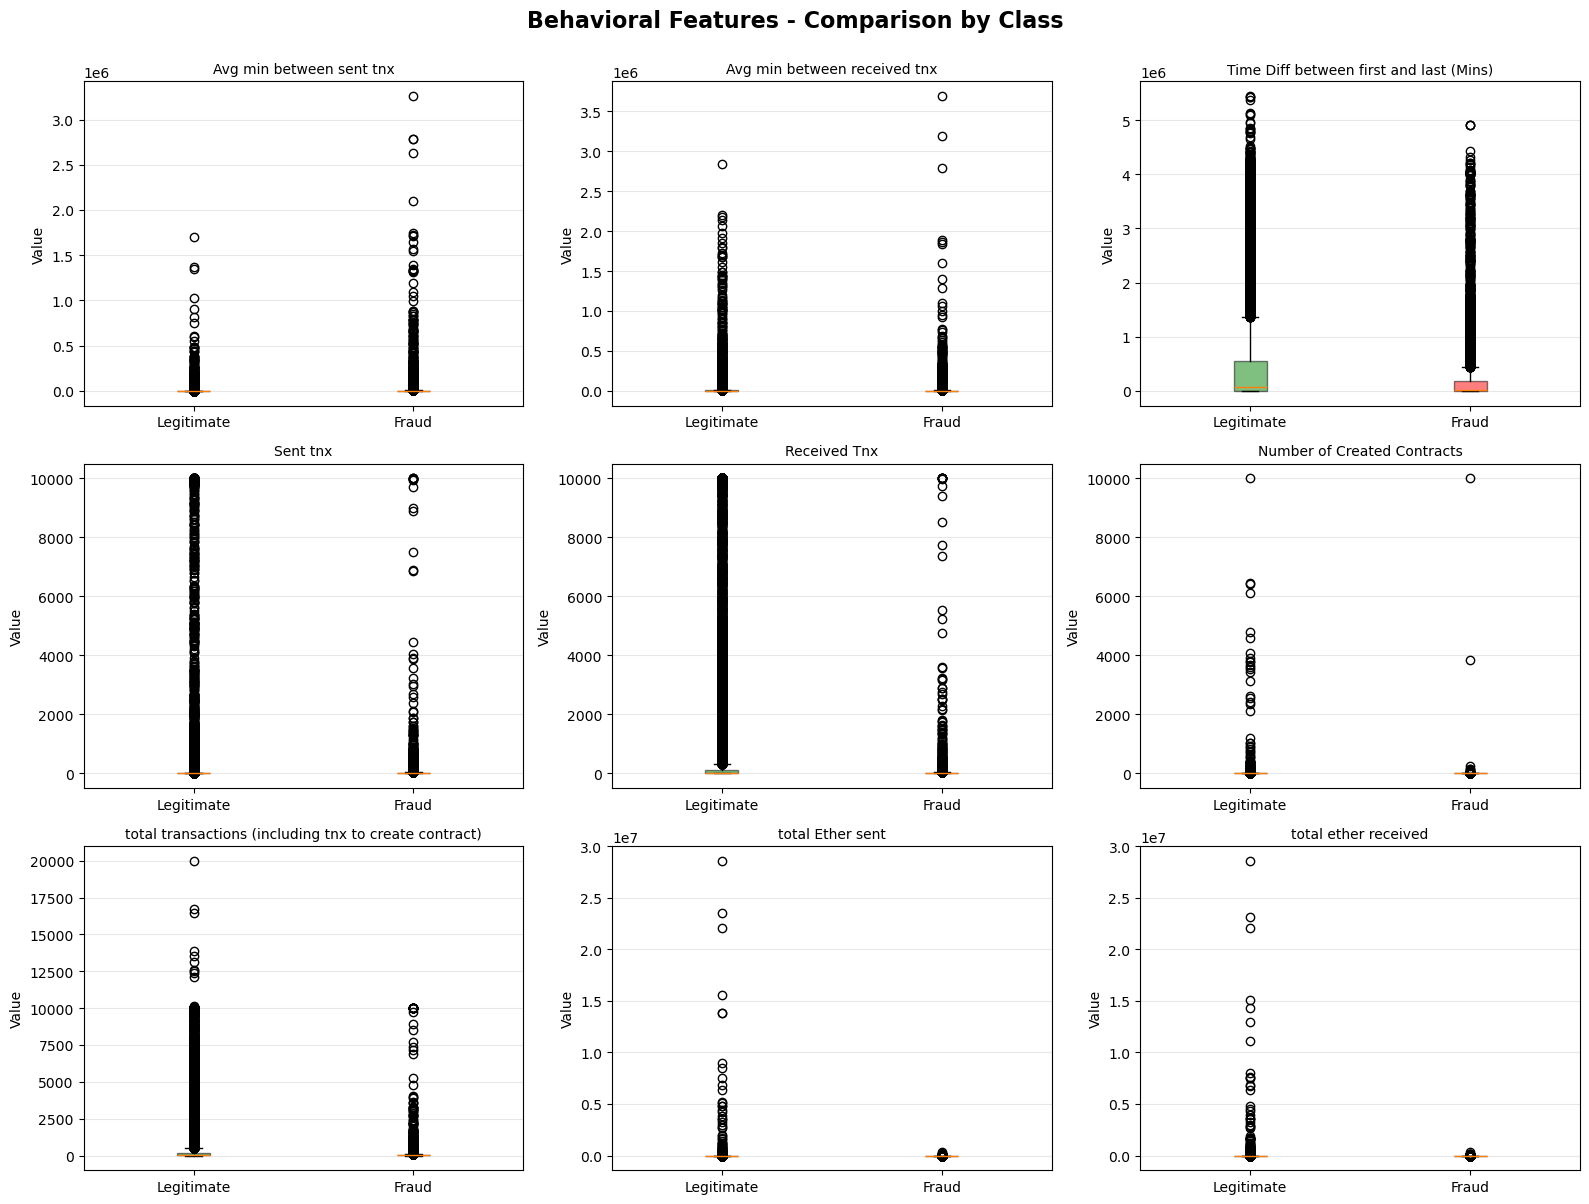

In [8]:
# Boxplots for behavioral features by class
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, feature in enumerate(BEHAVIORAL_FEATURES):
    data_to_plot = [X_behavioral[y==0][feature], X_behavioral[y==1][feature]]
    bp = axes[i].boxplot(data_to_plot, labels=['Legitimate', 'Fraud'], patch_artist=True)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('red')
    bp['boxes'][1].set_alpha(0.5)
    
    axes[i].set_title(f'{feature}', fontsize=10)
    axes[i].set_ylabel('Value')
    axes[i].grid(alpha=0.3, axis='y')

plt.suptitle('Behavioral Features - Comparison by Class', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

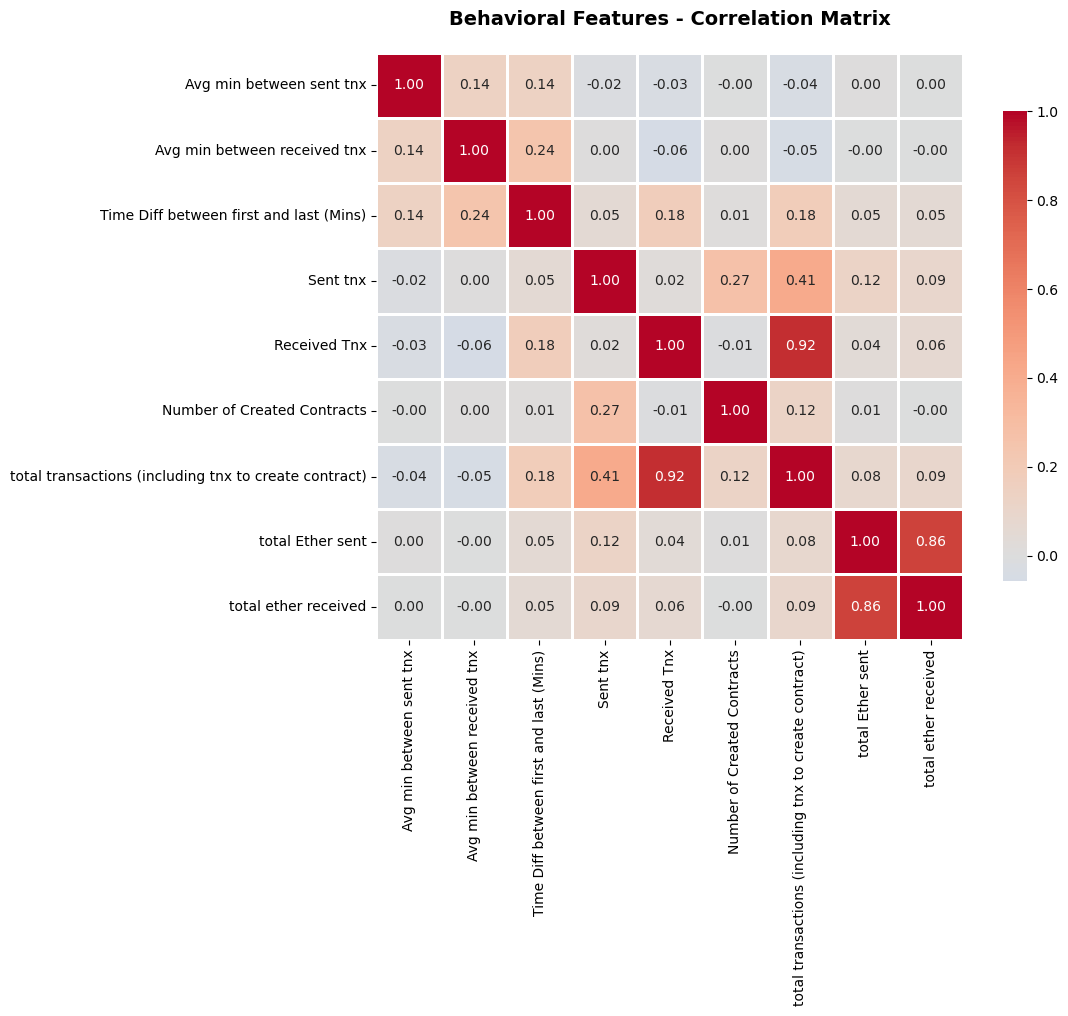


Highly Correlated Behavioral Feature Pairs (|r| > 0.7):
  Received Tnx                             <-> total transactions (including tnx to create contract): +0.919
  total Ether sent                         <-> total ether received                    : +0.857


In [9]:
# Correlation matrix for behavioral features
plt.figure(figsize=(12, 10))
correlation_matrix_beh = X_behavioral.corr()
sns.heatmap(correlation_matrix_beh, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Behavioral Features - Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identify highly correlated features (|correlation| > 0.7)
print("\nHighly Correlated Behavioral Feature Pairs (|r| > 0.7):")
print("="*70)
high_corr = []
for i in range(len(correlation_matrix_beh.columns)):
    for j in range(i+1, len(correlation_matrix_beh.columns)):
        if abs(correlation_matrix_beh.iloc[i, j]) > 0.7:
            high_corr.append((correlation_matrix_beh.columns[i], 
                            correlation_matrix_beh.columns[j], 
                            correlation_matrix_beh.iloc[i, j]))
            print(f"  {correlation_matrix_beh.columns[i]:40s} <-> {correlation_matrix_beh.columns[j]:40s}: {correlation_matrix_beh.iloc[i, j]:+.3f}")

if not high_corr:
    print("  No highly correlated pairs found.")

### 5.3 Association Dimension Analysis

ASSOCIATION DIMENSION - STATISTICAL SUMMARY
                                                      count        mean  \
No. of txns from blacklisted addresses              28406.0    1.691122   
No. of txns to blacklisted addresses                28406.0    0.253010   
Total ether sent to blacklisted addresses           28406.0   71.068095   
Ratio of total sent to blacklisted addresses        28406.0    0.032663   
Total ether received from blacklisted addresses     28406.0  103.441961   
Ratio of total received from blacklisted addresses  28406.0    0.044276   
unique_wallets_interacted_with                      28406.0  253.010139   
num_blacklisted_contracts_interacted                28406.0    0.021897   
ratio_blacklisted_contract_txns                     28406.0    0.003193   

                                                            std  min  25%  \
No. of txns from blacklisted addresses                41.470309  0.0  0.0   
No. of txns to blacklisted addresses               

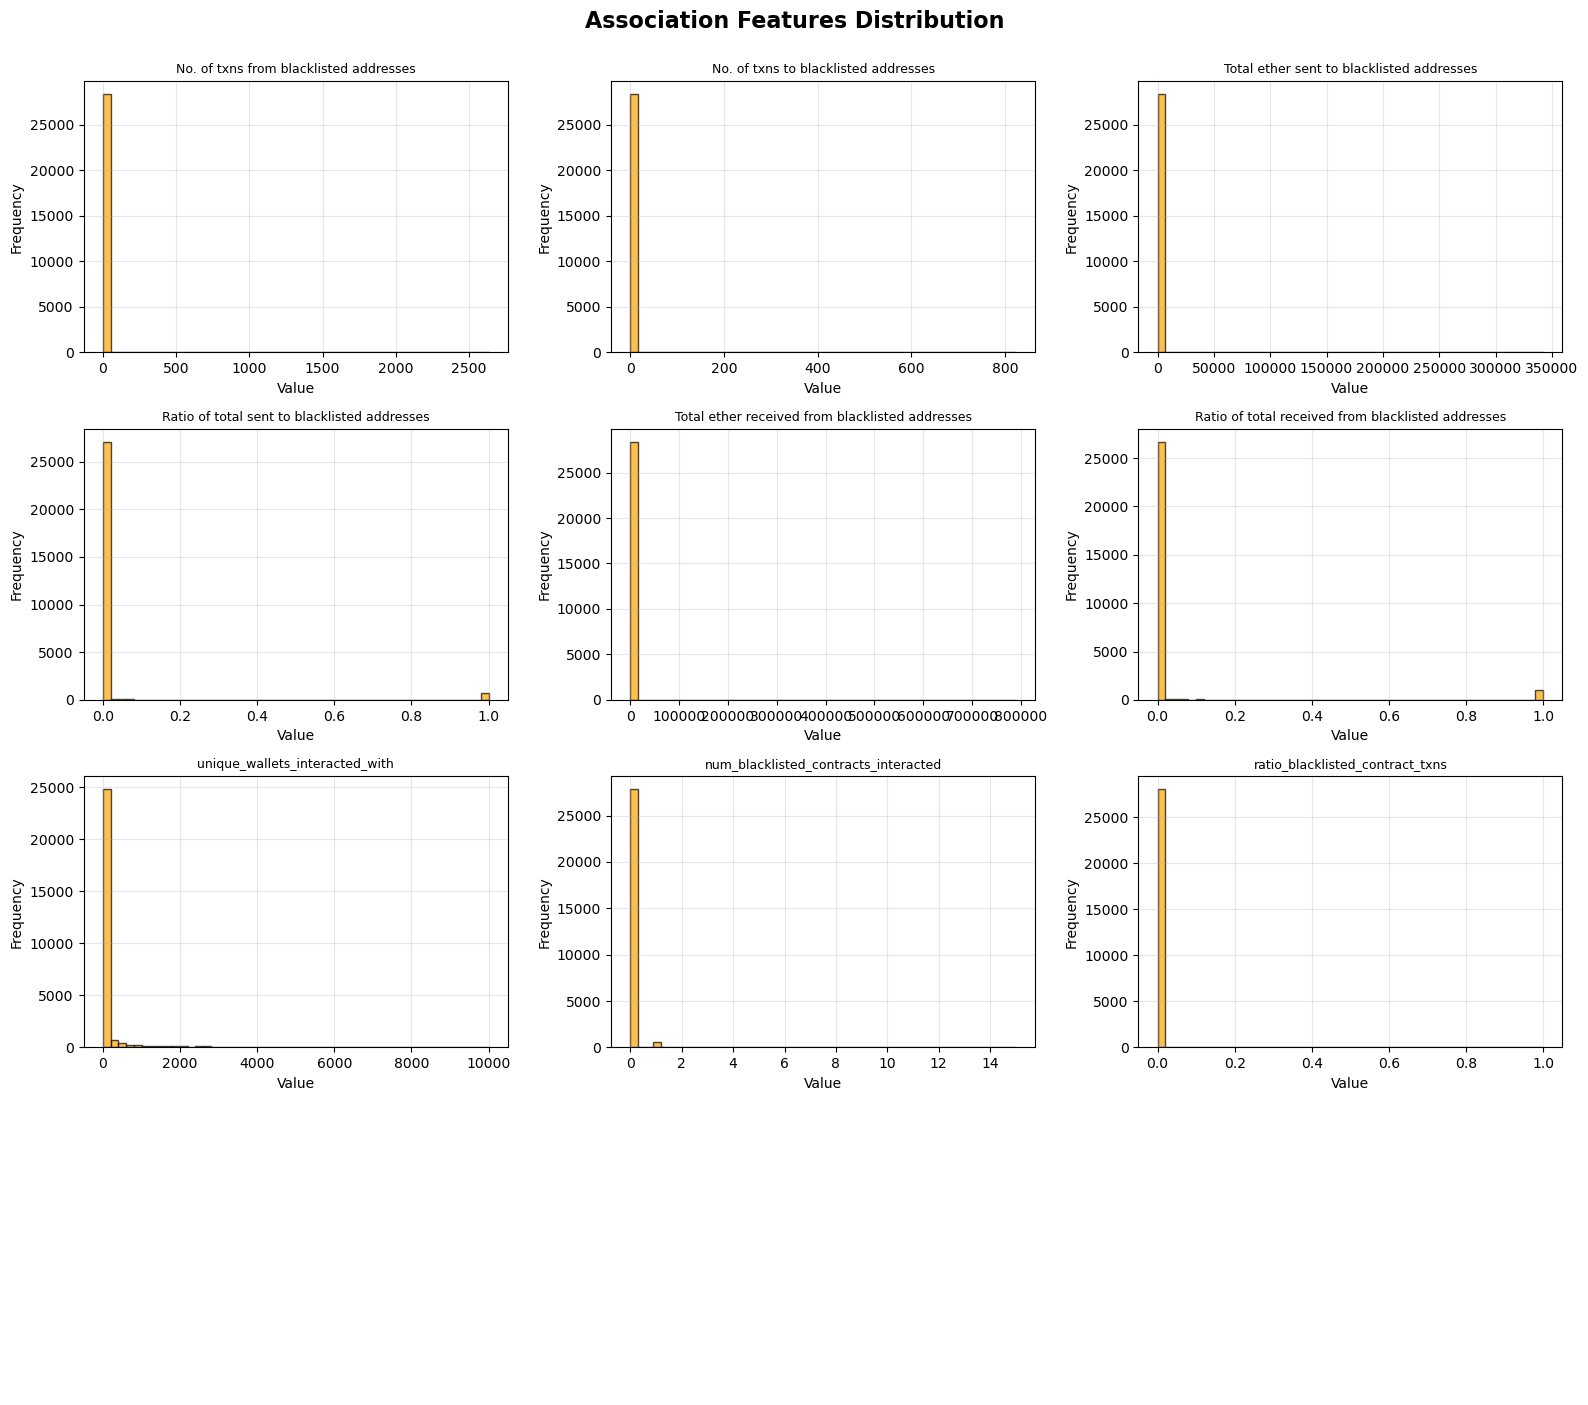

In [10]:
# Statistical summary for association features
print("="*70)
print("ASSOCIATION DIMENSION - STATISTICAL SUMMARY")
print("="*70)
print(X_association.describe().T)

# Check for missing values
print("\n" + "="*70)
print("Missing Values:")
print("="*70)
print(X_association.isnull().sum())

# Distribution of association features
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.ravel()

for i, feature in enumerate(ASSOCIATION_FEATURES):
    axes[i].hist(X_association[feature], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[i].set_title(f'{feature}', fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)

# Hide unused subplots
for i in range(len(ASSOCIATION_FEATURES), len(axes)):
    axes[i].axis('off')

plt.suptitle('Association Features Distribution', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

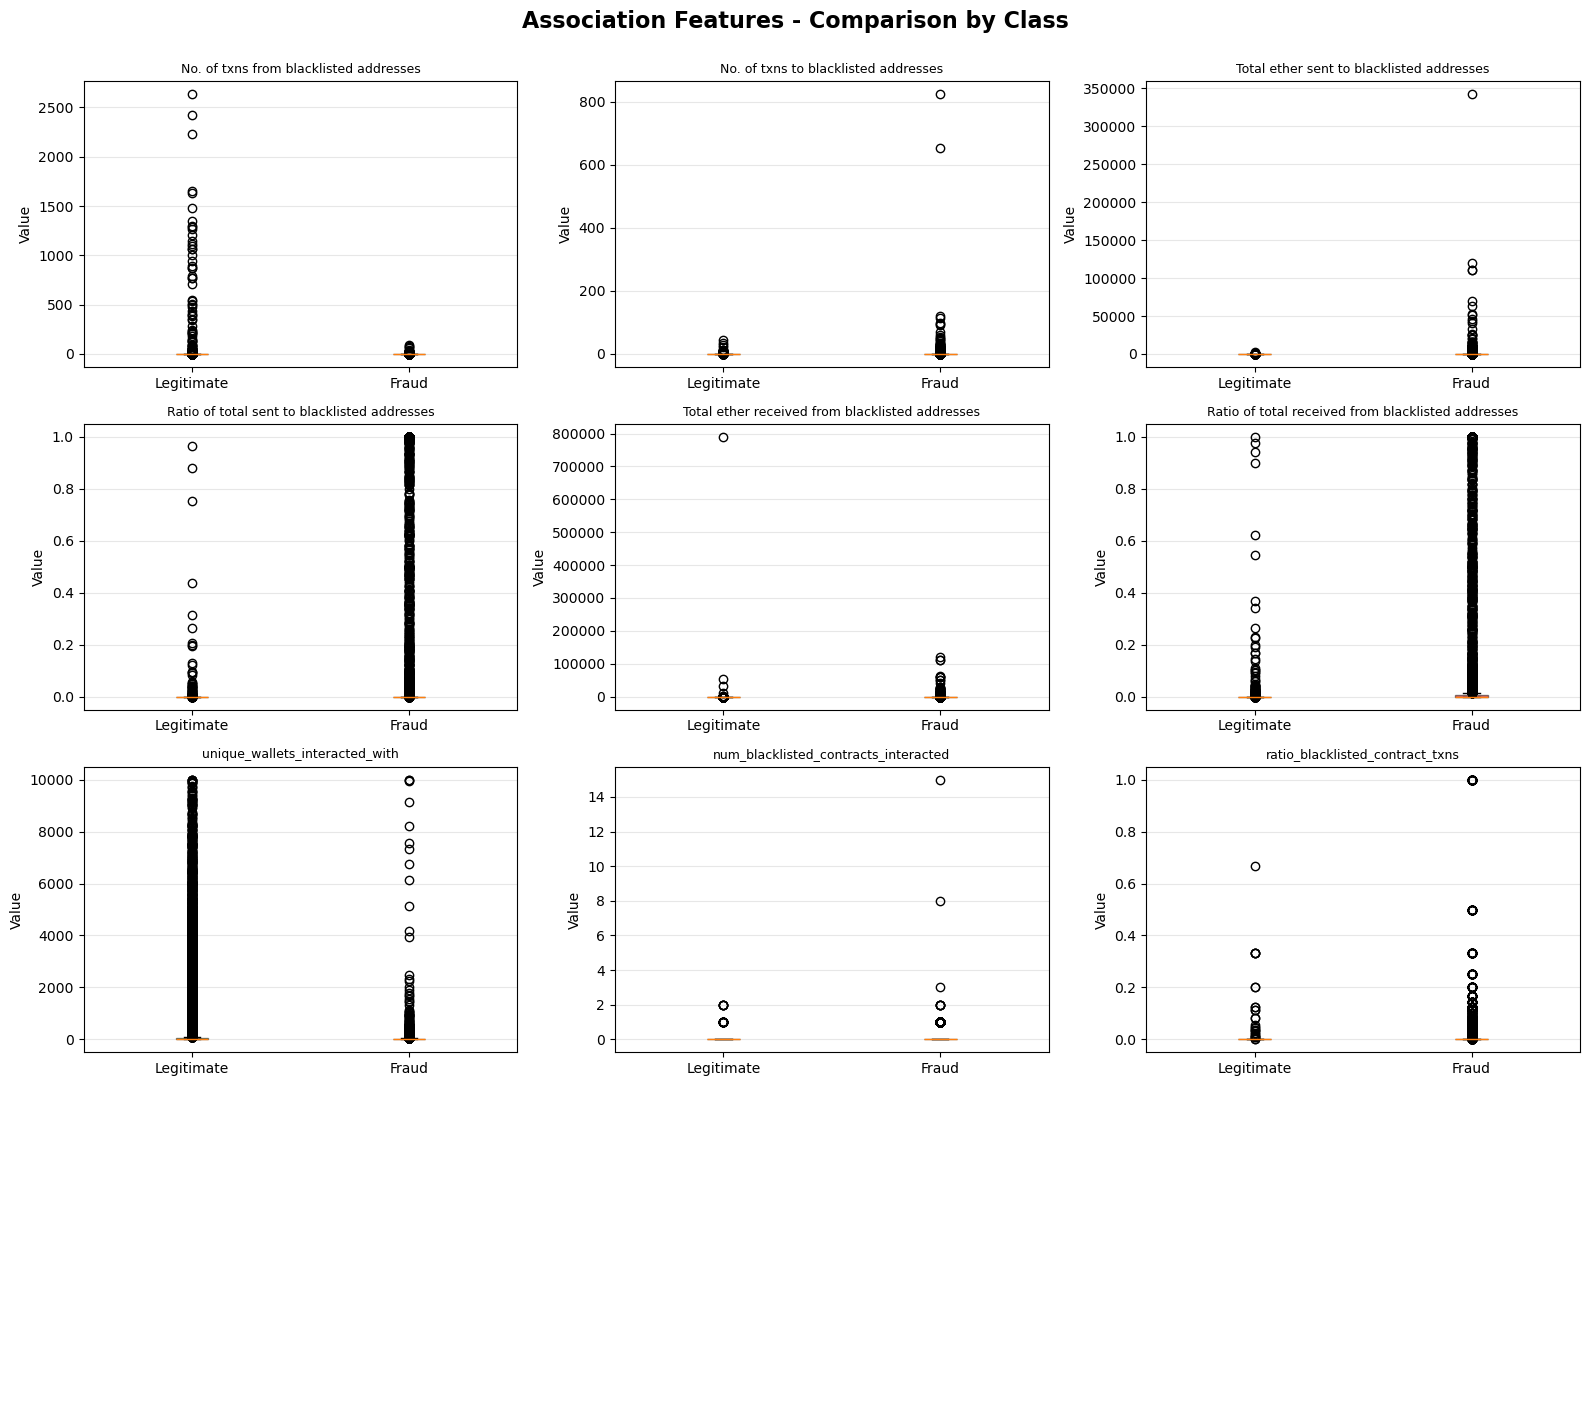

In [11]:
# Boxplots for association features by class
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.ravel()

for i, feature in enumerate(ASSOCIATION_FEATURES):
    data_to_plot = [X_association[y==0][feature], X_association[y==1][feature]]
    bp = axes[i].boxplot(data_to_plot, labels=['Legitimate', 'Fraud'], patch_artist=True)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('red')
    bp['boxes'][1].set_alpha(0.5)
    
    axes[i].set_title(f'{feature}', fontsize=9)
    axes[i].set_ylabel('Value')
    axes[i].grid(alpha=0.3, axis='y')

# Hide unused subplots
for i in range(len(ASSOCIATION_FEATURES), len(axes)):
    axes[i].axis('off')

plt.suptitle('Association Features - Comparison by Class', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

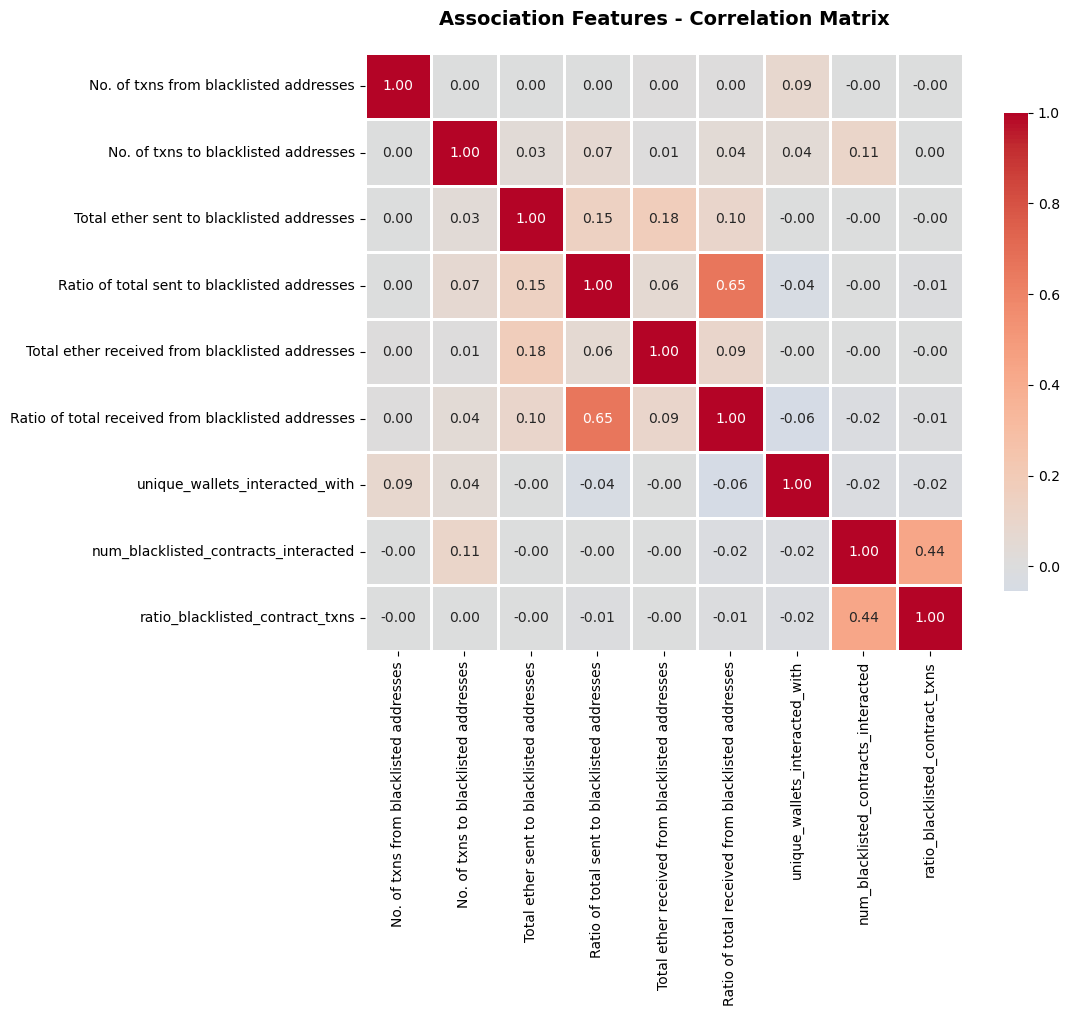


Highly Correlated Association Feature Pairs (|r| > 0.7):
  No highly correlated pairs found.


In [12]:
# Correlation matrix for association features
plt.figure(figsize=(12, 10))
correlation_matrix_ass = X_association.corr()
sns.heatmap(correlation_matrix_ass, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Association Features - Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identify highly correlated features (|correlation| > 0.7)
print("\nHighly Correlated Association Feature Pairs (|r| > 0.7):")
print("="*70)
high_corr = []
for i in range(len(correlation_matrix_ass.columns)):
    for j in range(i+1, len(correlation_matrix_ass.columns)):
        if abs(correlation_matrix_ass.iloc[i, j]) > 0.7:
            high_corr.append((correlation_matrix_ass.columns[i], 
                            correlation_matrix_ass.columns[j], 
                            correlation_matrix_ass.iloc[i, j]))
            print(f"  {correlation_matrix_ass.columns[i]:40s} <-> {correlation_matrix_ass.columns[j]:40s}: {correlation_matrix_ass.iloc[i, j]:+.3f}")

if not high_corr:
    print("  No highly correlated pairs found.")

### 5.4 Contextual Dimension Analysis

CONTEXTUAL DIMENSION - STATISTICAL SUMMARY
                                     count       mean          std  min  \
avg_gas_price_gwei                 28406.0  25.899291   182.351082  0.0   
gas_price_std_dev                  28406.0  40.077219  2803.944825  0.0   
high_gas_price_ratio               28406.0   0.115955     0.123805  0.0   
low_gas_price_ratio                28406.0   0.174781     0.217309  0.0   
gas_price_coefficient_variation    28406.0   0.644849     1.041069  0.0   
total_failed_txns                  28406.0  49.801098   304.251327  0.0   
failed_txn_ratio                   28406.0   0.035239     0.099275  0.0   
max_consecutive_failures           28406.0   8.224248   113.092273  0.0   
failed_contract_interaction_ratio  28406.0   0.335200     0.471663  0.0   
total_erc721_transfers             28406.0   0.000000     0.000000  0.0   
erc721_incoming_ratio              28406.0   0.000000     0.000000  0.0   
erc721_outgoing_ratio              28406.0   0.000000    

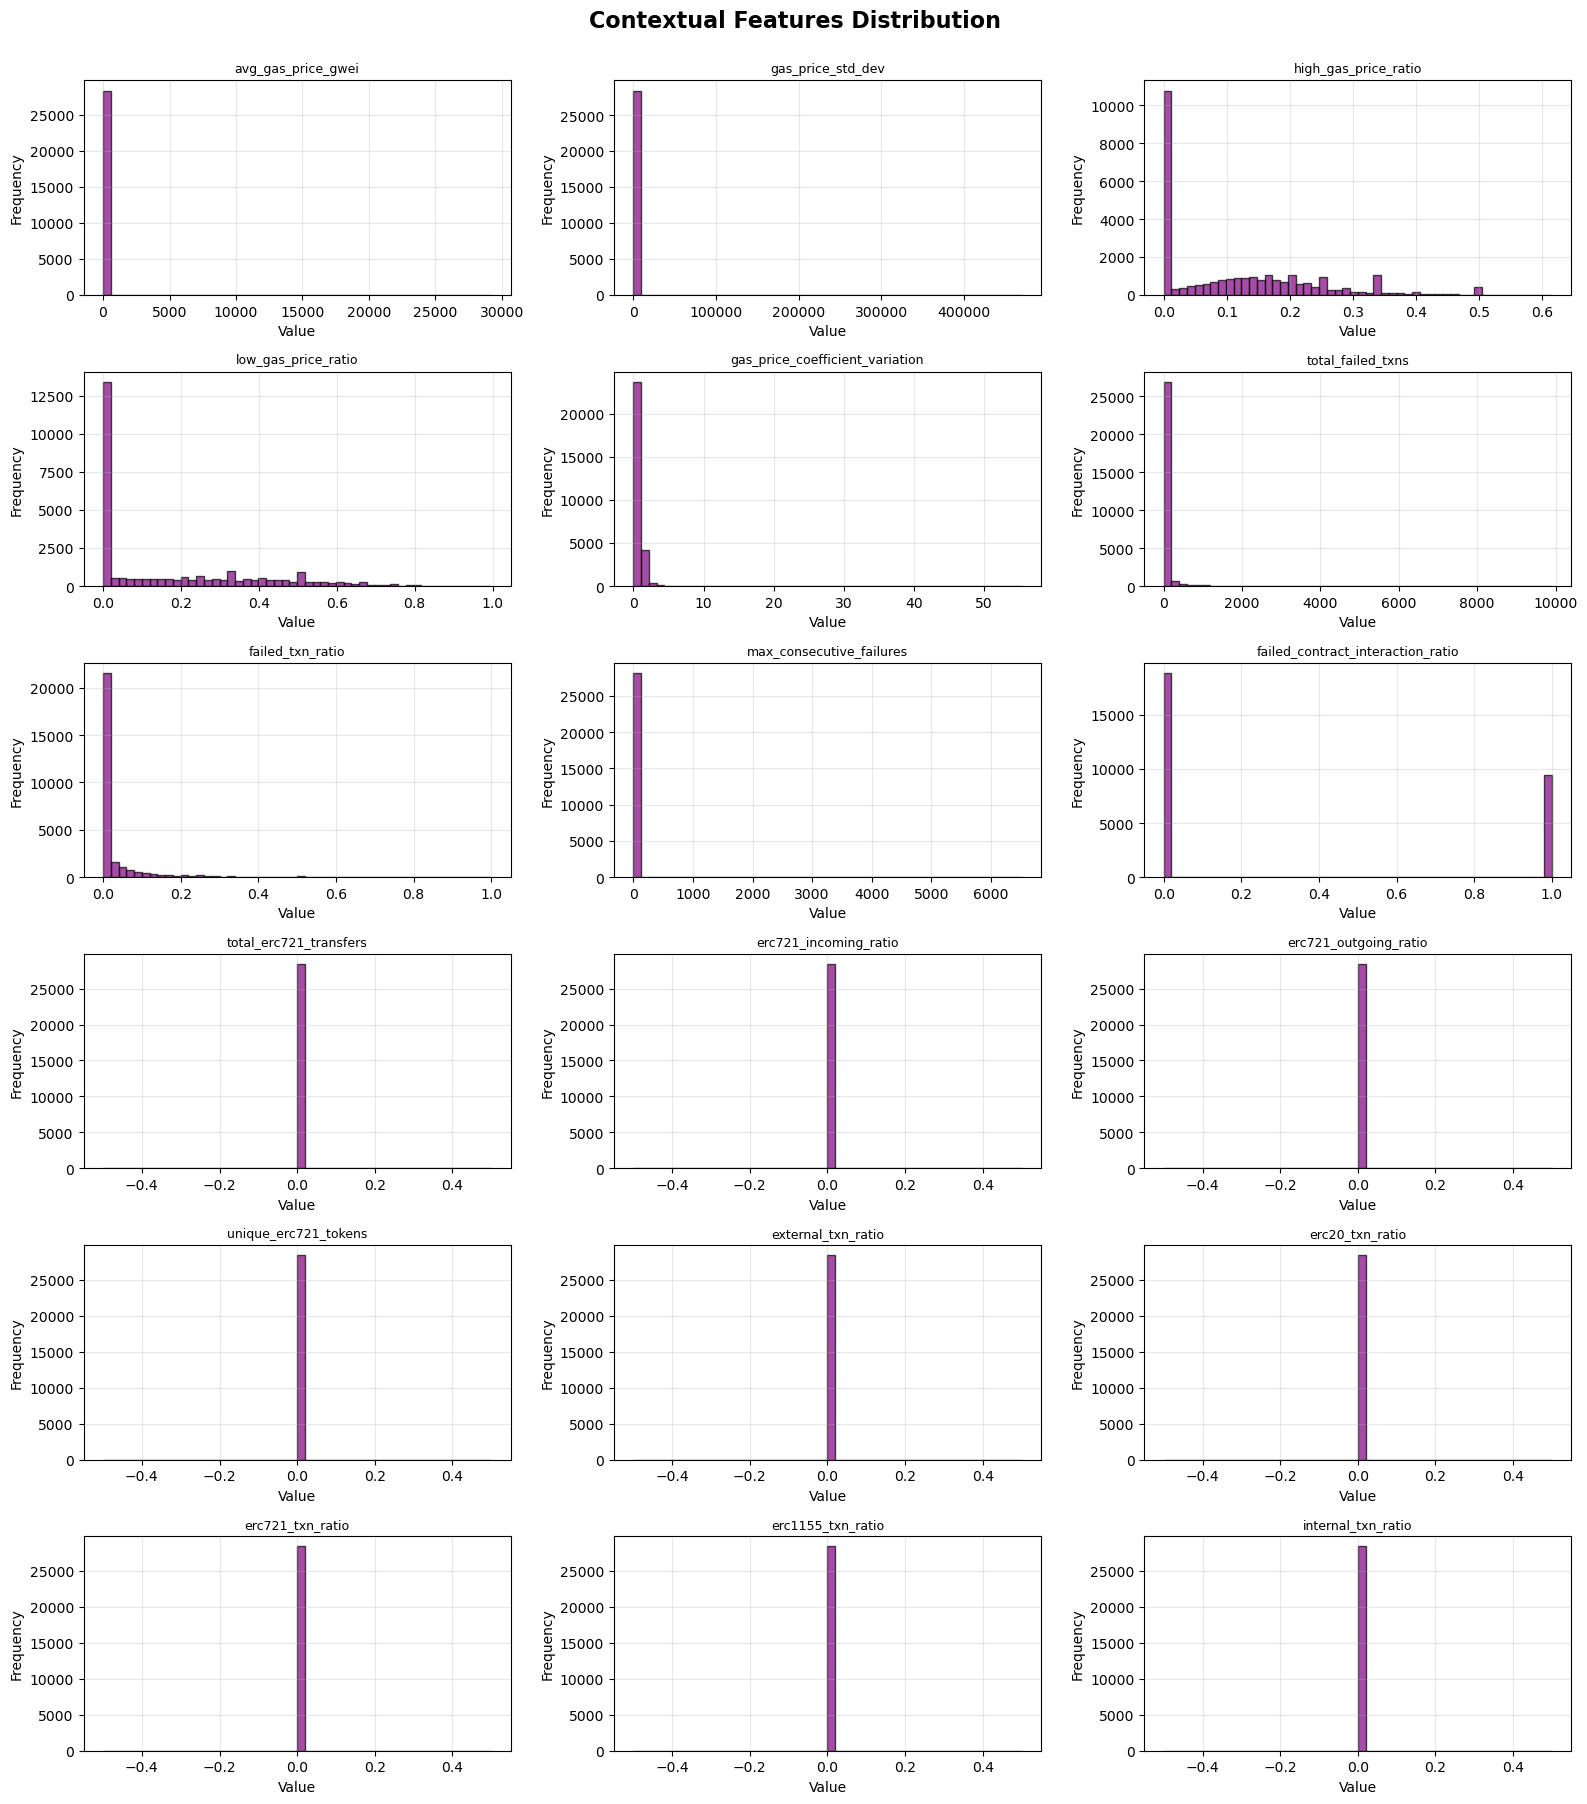

In [13]:
# Statistical summary for contextual features
print("="*70)
print("CONTEXTUAL DIMENSION - STATISTICAL SUMMARY")
print("="*70)
print(X_contextual.describe().T)

# Check for missing values
print("\n" + "="*70)
print("Missing Values:")
print("="*70)
print(X_contextual.isnull().sum())

# Distribution of contextual features
fig, axes = plt.subplots(6, 3, figsize=(16, 18))
axes = axes.ravel()

for i, feature in enumerate(CONTEXTUAL_FEATURES):
    axes[i].hist(X_contextual[feature], bins=50, edgecolor='black', alpha=0.7, color='purple')
    axes[i].set_title(f'{feature}', fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)

plt.suptitle('Contextual Features Distribution', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

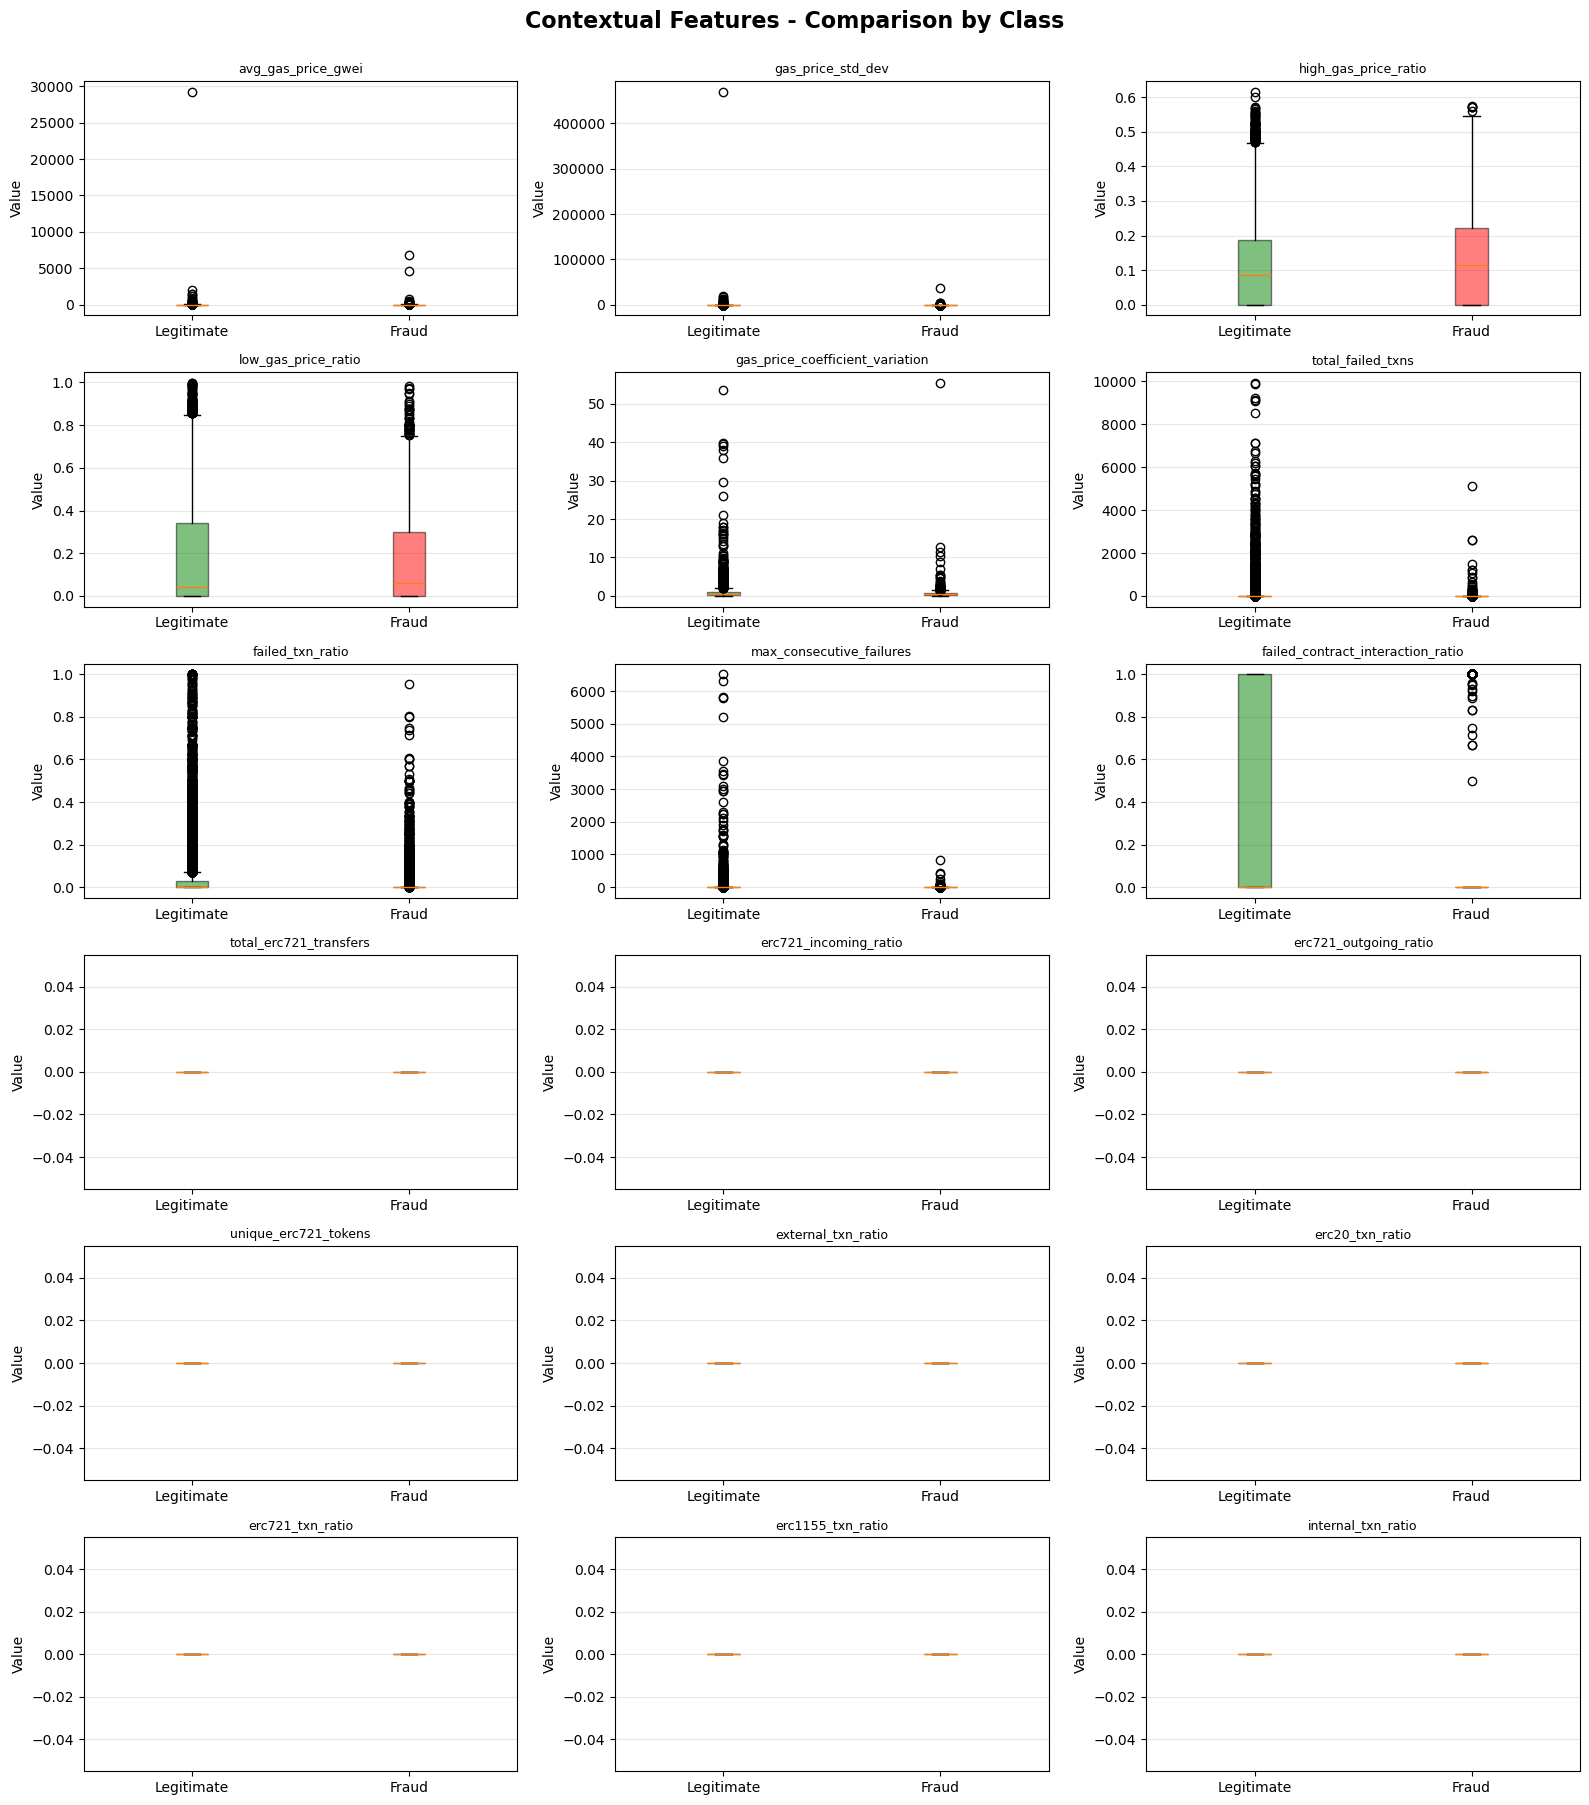

In [14]:
# Boxplots for contextual features by class
fig, axes = plt.subplots(6, 3, figsize=(16, 18))
axes = axes.ravel()

for i, feature in enumerate(CONTEXTUAL_FEATURES):
    data_to_plot = [X_contextual[y==0][feature], X_contextual[y==1][feature]]
    bp = axes[i].boxplot(data_to_plot, labels=['Legitimate', 'Fraud'], patch_artist=True)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('red')
    bp['boxes'][1].set_alpha(0.5)
    
    axes[i].set_title(f'{feature}', fontsize=9)
    axes[i].set_ylabel('Value')
    axes[i].grid(alpha=0.3, axis='y')

plt.suptitle('Contextual Features - Comparison by Class', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

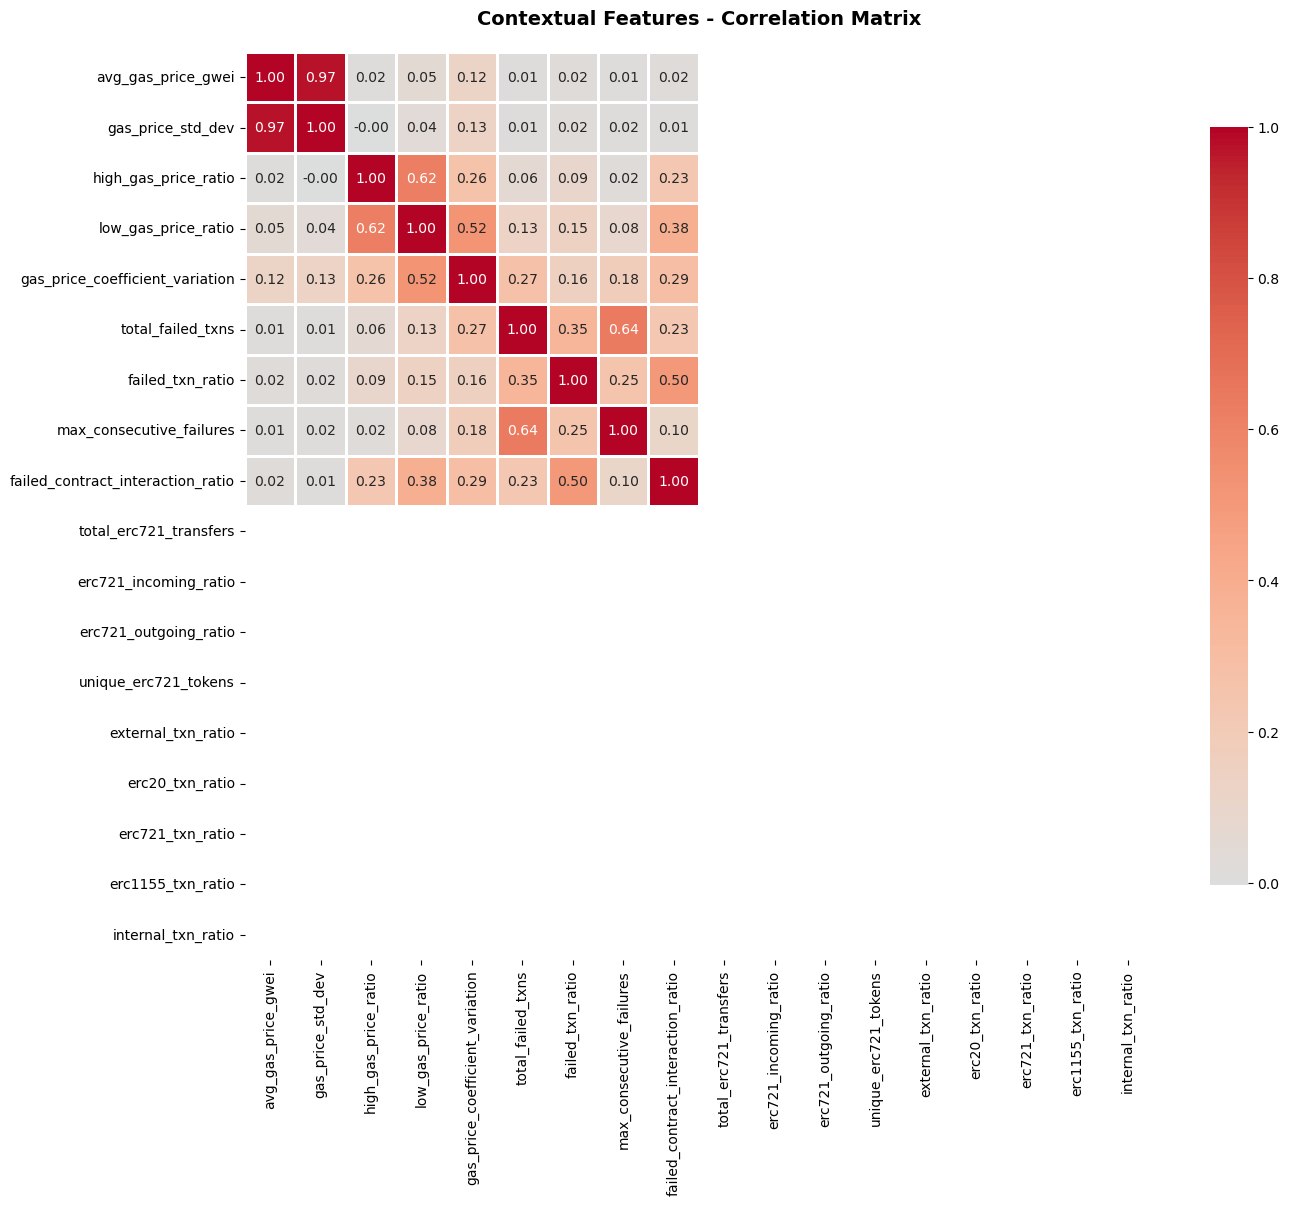


Highly Correlated Contextual Feature Pairs (|r| > 0.7):
  avg_gas_price_gwei                       <-> gas_price_std_dev                       : +0.970


In [15]:
# Correlation matrix for contextual features
plt.figure(figsize=(14, 12))
correlation_matrix_ctx = X_contextual.corr()
sns.heatmap(correlation_matrix_ctx, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Contextual Features - Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identify highly correlated features (|correlation| > 0.7)
print("\nHighly Correlated Contextual Feature Pairs (|r| > 0.7):")
print("="*70)
high_corr = []
for i in range(len(correlation_matrix_ctx.columns)):
    for j in range(i+1, len(correlation_matrix_ctx.columns)):
        if abs(correlation_matrix_ctx.iloc[i, j]) > 0.7:
            high_corr.append((correlation_matrix_ctx.columns[i], 
                            correlation_matrix_ctx.columns[j], 
                            correlation_matrix_ctx.iloc[i, j]))
            print(f"  {correlation_matrix_ctx.columns[i]:40s} <-> {correlation_matrix_ctx.columns[j]:40s}: {correlation_matrix_ctx.iloc[i, j]:+.3f}")

if not high_corr:
    print("  No highly correlated pairs found.")

### 5.5 Feature Distribution Histograms

Examining the distribution of key features from each dimension

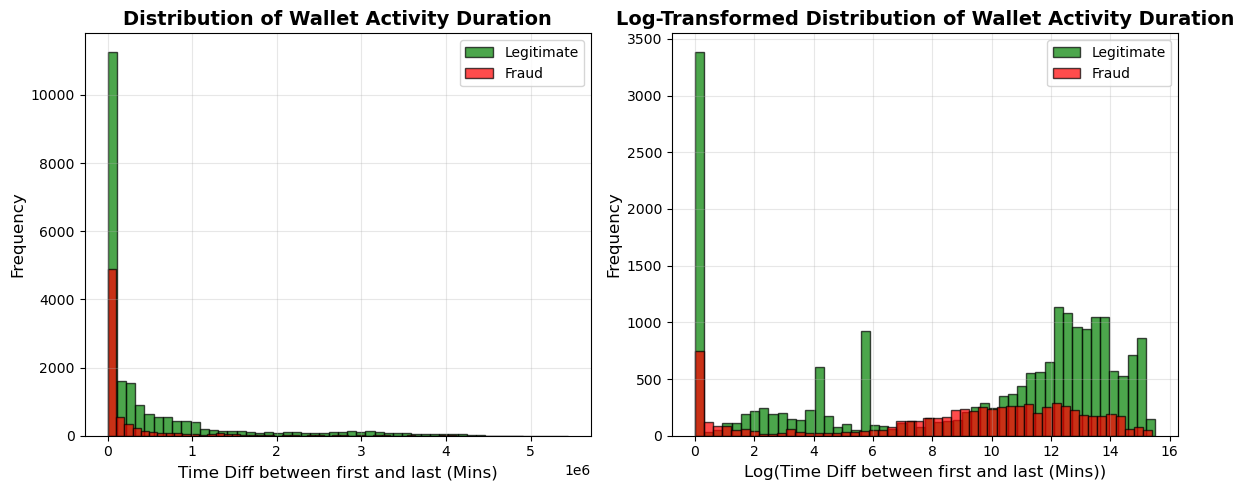

Statistics for 'Time Diff between first and last (Mins)':
Legitimate wallets - Mean: 498796.68, Median: 79724.37
Fraud wallets - Mean: 248476.97, Median: 19776.50


In [16]:
# Histogram for 'Time Diff between first and last (Mins)' - Behavioral Dimension
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df[df['FLAG'] == 0]['Time Diff between first and last (Mins)'], 
         bins=50, alpha=0.7, label='Legitimate', color='green', edgecolor='black')
plt.hist(df[df['FLAG'] == 1]['Time Diff between first and last (Mins)'], 
         bins=50, alpha=0.7, label='Fraud', color='red', edgecolor='black')
plt.xlabel('Time Diff between first and last (Mins)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Wallet Activity Duration', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df[df['FLAG'] == 0]['Time Diff between first and last (Mins)']), 
         bins=50, alpha=0.7, label='Legitimate', color='green', edgecolor='black')
plt.hist(np.log1p(df[df['FLAG'] == 1]['Time Diff between first and last (Mins)']), 
         bins=50, alpha=0.7, label='Fraud', color='red', edgecolor='black')
plt.xlabel('Log(Time Diff between first and last (Mins))', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Log-Transformed Distribution of Wallet Activity Duration', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Statistics for 'Time Diff between first and last (Mins)':")
print(f"Legitimate wallets - Mean: {df[df['FLAG'] == 0]['Time Diff between first and last (Mins)'].mean():.2f}, Median: {df[df['FLAG'] == 0]['Time Diff between first and last (Mins)'].median():.2f}")
print(f"Fraud wallets - Mean: {df[df['FLAG'] == 1]['Time Diff between first and last (Mins)'].mean():.2f}, Median: {df[df['FLAG'] == 1]['Time Diff between first and last (Mins)'].median():.2f}")

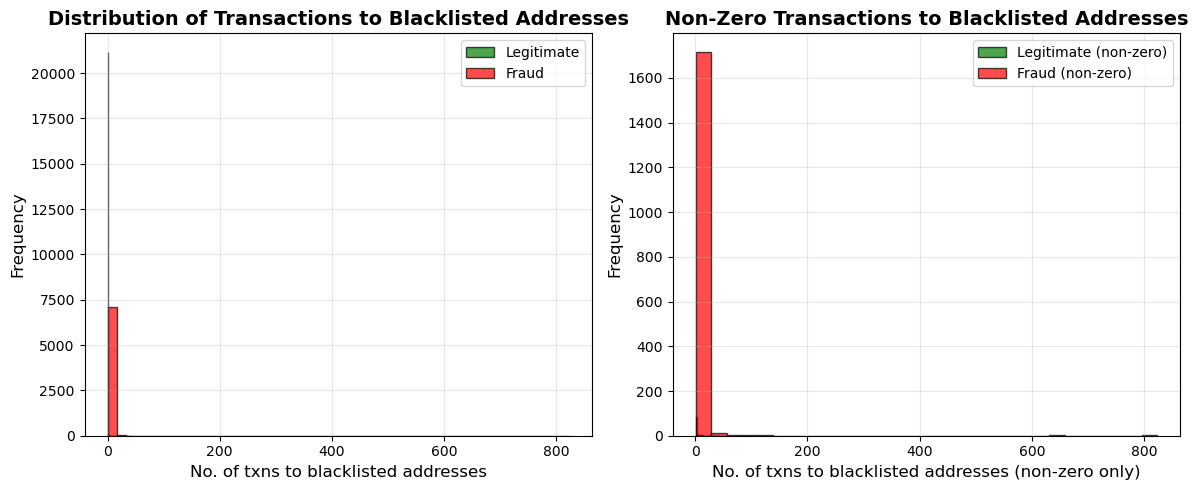

Statistics for 'No. of txns to blacklisted addresses':
Legitimate wallets - Mean: 0.02, Median: 0.00
Fraud wallets - Mean: 0.95, Median: 0.00
Legitimate with blacklist txns: 118 / 21257
Fraud with blacklist txns: 1734 / 7149


In [17]:
# Histogram for 'No. of txns to blacklisted addresses' - Association Dimension
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df[df['FLAG'] == 0]['No. of txns to blacklisted addresses'], 
         bins=50, alpha=0.7, label='Legitimate', color='green', edgecolor='black')
plt.hist(df[df['FLAG'] == 1]['No. of txns to blacklisted addresses'], 
         bins=50, alpha=0.7, label='Fraud', color='red', edgecolor='black')
plt.xlabel('No. of txns to blacklisted addresses', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Transactions to Blacklisted Addresses', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
# Only plot non-zero values for better visibility
legitimate_nonzero = df[df['FLAG'] == 0]['No. of txns to blacklisted addresses']
fraud_nonzero = df[df['FLAG'] == 1]['No. of txns to blacklisted addresses']

legitimate_nonzero = legitimate_nonzero[legitimate_nonzero > 0]
fraud_nonzero = fraud_nonzero[fraud_nonzero > 0]

plt.hist(legitimate_nonzero, bins=30, alpha=0.7, label='Legitimate (non-zero)', color='green', edgecolor='black')
plt.hist(fraud_nonzero, bins=30, alpha=0.7, label='Fraud (non-zero)', color='red', edgecolor='black')
plt.xlabel('No. of txns to blacklisted addresses (non-zero only)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Non-Zero Transactions to Blacklisted Addresses', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Statistics for 'No. of txns to blacklisted addresses':")
print(f"Legitimate wallets - Mean: {df[df['FLAG'] == 0]['No. of txns to blacklisted addresses'].mean():.2f}, Median: {df[df['FLAG'] == 0]['No. of txns to blacklisted addresses'].median():.2f}")
print(f"Fraud wallets - Mean: {df[df['FLAG'] == 1]['No. of txns to blacklisted addresses'].mean():.2f}, Median: {df[df['FLAG'] == 1]['No. of txns to blacklisted addresses'].median():.2f}")
print(f"Legitimate with blacklist txns: {(df[df['FLAG'] == 0]['No. of txns to blacklisted addresses'] > 0).sum()} / {(df['FLAG'] == 0).sum()}")
print(f"Fraud with blacklist txns: {(df[df['FLAG'] == 1]['No. of txns to blacklisted addresses'] > 0).sum()} / {(df['FLAG'] == 1).sum()}")

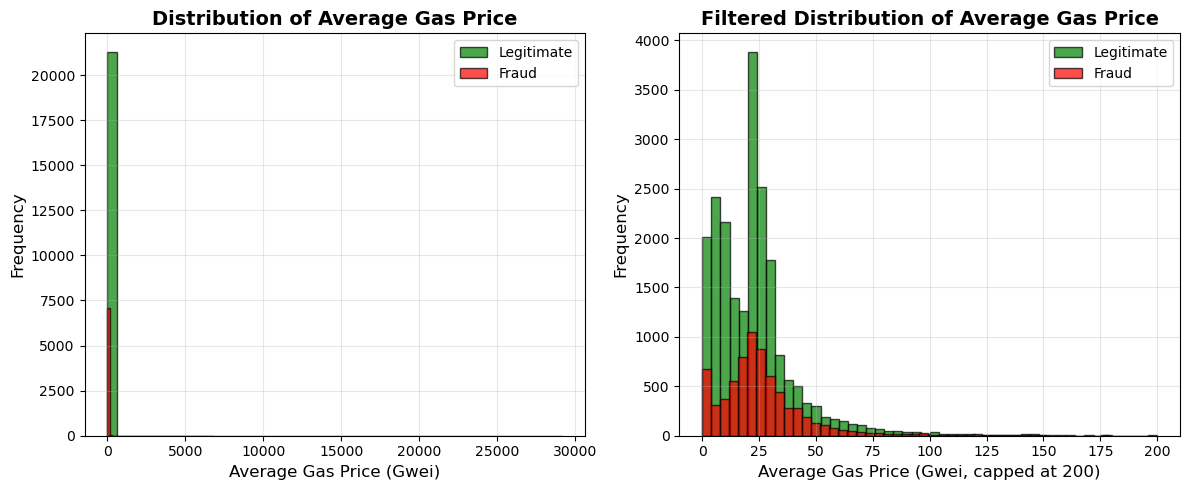

Statistics for 'avg_gas_price_gwei':
Legitimate wallets - Mean: 24.93, Median: 21.73
Fraud wallets - Mean: 28.77, Median: 23.00
Legitimate (within 0-200 Gwei): 21224 / 21257
Fraud (within 0-200 Gwei): 7128 / 7149


In [18]:
# Histogram for 'avg_gas_price_gwei' - Contextual Dimension
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df[df['FLAG'] == 0]['avg_gas_price_gwei'], 
         bins=50, alpha=0.7, label='Legitimate', color='green', edgecolor='black')
plt.hist(df[df['FLAG'] == 1]['avg_gas_price_gwei'], 
         bins=50, alpha=0.7, label='Fraud', color='red', edgecolor='black')
plt.xlabel('Average Gas Price (Gwei)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Average Gas Price', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
# Focus on reasonable gas price range (filter outliers)
max_gas = 200  # Gwei
legitimate_filtered = df[(df['FLAG'] == 0) & (df['avg_gas_price_gwei'] <= max_gas)]['avg_gas_price_gwei']
fraud_filtered = df[(df['FLAG'] == 1) & (df['avg_gas_price_gwei'] <= max_gas)]['avg_gas_price_gwei']

plt.hist(legitimate_filtered, bins=50, alpha=0.7, label='Legitimate', color='green', edgecolor='black')
plt.hist(fraud_filtered, bins=50, alpha=0.7, label='Fraud', color='red', edgecolor='black')
plt.xlabel('Average Gas Price (Gwei, capped at 200)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Filtered Distribution of Average Gas Price', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Statistics for 'avg_gas_price_gwei':")
print(f"Legitimate wallets - Mean: {df[df['FLAG'] == 0]['avg_gas_price_gwei'].mean():.2f}, Median: {df[df['FLAG'] == 0]['avg_gas_price_gwei'].median():.2f}")
print(f"Fraud wallets - Mean: {df[df['FLAG'] == 1]['avg_gas_price_gwei'].mean():.2f}, Median: {df[df['FLAG'] == 1]['avg_gas_price_gwei'].median():.2f}")
print(f"Legitimate (within 0-200 Gwei): {len(legitimate_filtered)} / {(df['FLAG'] == 0).sum()}")
print(f"Fraud (within 0-200 Gwei): {len(fraud_filtered)} / {(df['FLAG'] == 1).sum()}")

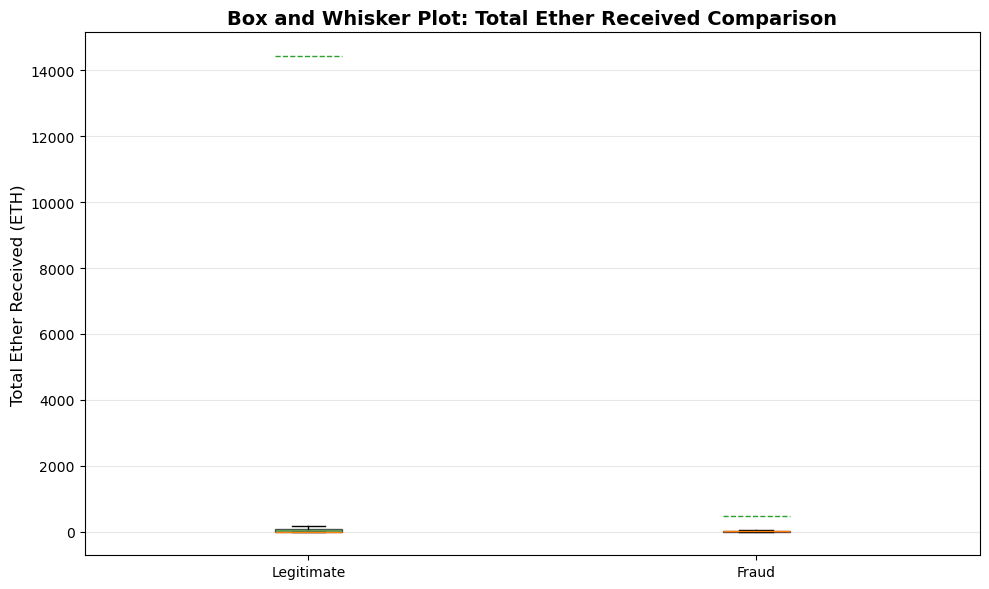

Statistical Summary for 'total ether received':

Legitimate Wallets:
  Mean: 14,433.27 ETH
  Median: 0.11 ETH
  Std Dev: 384,031.63 ETH
  Q1 (25%): 0.00 ETH
  Q3 (75%): 62.23 ETH

Fraud Wallets:
  Mean: 460.66 ETH
  Median: 2.71 ETH
  Std Dev: 5,657.28 ETH
  Q1 (25%): 0.12 ETH
  Q3 (75%): 20.00 ETH

Difference (Legitimate - Fraud):
  Mean difference: 13,972.61 ETH
  Median difference: -2.60 ETH


In [19]:
# Box and Whisker Plot: total ether received
plt.figure(figsize=(10, 6))

# Prepare data
data_to_plot = [
    df[df['FLAG'] == 0]['total ether received'],
    df[df['FLAG'] == 1]['total ether received']
]

# Create box plot (outliers hidden for better visibility)
bp = plt.boxplot(data_to_plot, labels=['Legitimate', 'Fraud'], patch_artist=True,
                 showmeans=True, meanline=True, showfliers=False)

# Color the boxes
bp['boxes'][0].set_facecolor('green')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.6)

plt.ylabel('Total Ether Received (ETH)', fontsize=12)
plt.title('Box and Whisker Plot: Total Ether Received Comparison', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Statistical summary
print("Statistical Summary for 'total ether received':")
print("\nLegitimate Wallets:")
print(f"  Mean: {df[df['FLAG'] == 0]['total ether received'].mean():,.2f} ETH")
print(f"  Median: {df[df['FLAG'] == 0]['total ether received'].median():,.2f} ETH")
print(f"  Std Dev: {df[df['FLAG'] == 0]['total ether received'].std():,.2f} ETH")
print(f"  Q1 (25%): {df[df['FLAG'] == 0]['total ether received'].quantile(0.25):,.2f} ETH")
print(f"  Q3 (75%): {df[df['FLAG'] == 0]['total ether received'].quantile(0.75):,.2f} ETH")

print("\nFraud Wallets:")
print(f"  Mean: {df[df['FLAG'] == 1]['total ether received'].mean():,.2f} ETH")
print(f"  Median: {df[df['FLAG'] == 1]['total ether received'].median():,.2f} ETH")
print(f"  Std Dev: {df[df['FLAG'] == 1]['total ether received'].std():,.2f} ETH")
print(f"  Q1 (25%): {df[df['FLAG'] == 1]['total ether received'].quantile(0.25):,.2f} ETH")
print(f"  Q3 (75%): {df[df['FLAG'] == 1]['total ether received'].quantile(0.75):,.2f} ETH")

# Calculate difference
mean_diff = df[df['FLAG'] == 0]['total ether received'].mean() - df[df['FLAG'] == 1]['total ether received'].mean()
median_diff = df[df['FLAG'] == 0]['total ether received'].median() - df[df['FLAG'] == 1]['total ether received'].median()

print(f"\nDifference (Legitimate - Fraud):")
print(f"  Mean difference: {mean_diff:,.2f} ETH")
print(f"  Median difference: {median_diff:,.2f} ETH")

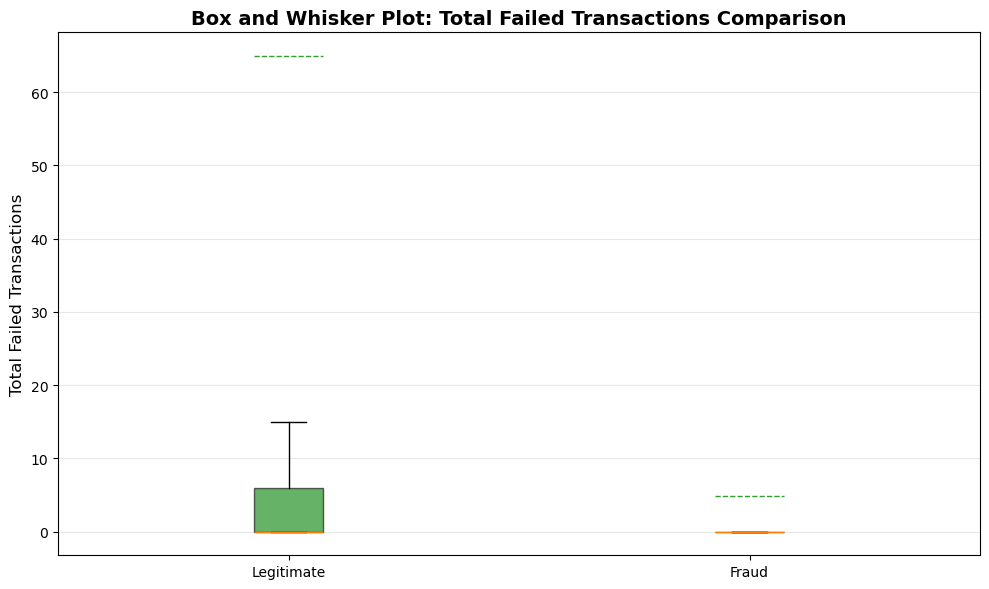

Statistical Summary for 'total_failed_txns':

Legitimate Wallets:
  Mean: 64.90
  Median: 0.00
  Std Dev: 347.07
  Q1 (25%): 0.00
  Q3 (75%): 6.00

Fraud Wallets:
  Mean: 4.90
  Median: 0.00
  Std Dev: 83.44
  Q1 (25%): 0.00
  Q3 (75%): 0.00

Difference (Legitimate - Fraud):
  Mean difference: 60.00
  Median difference: 0.00


In [20]:
# Box and Whisker Plot: total_failed_txns
plt.figure(figsize=(10, 6))

# Prepare data
data_to_plot = [
    df[df['FLAG'] == 0]['total_failed_txns'],
    df[df['FLAG'] == 1]['total_failed_txns']
]

# Create box plot (outliers hidden for better visibility)
bp = plt.boxplot(data_to_plot, labels=['Legitimate', 'Fraud'], patch_artist=True,
                 showmeans=True, meanline=True, showfliers=False)

# Color the boxes
bp['boxes'][0].set_facecolor('green')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.6)

plt.ylabel('Total Failed Transactions', fontsize=12)
plt.title('Box and Whisker Plot: Total Failed Transactions Comparison', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Statistical summary
print("Statistical Summary for 'total_failed_txns':")
print("\nLegitimate Wallets:")
print(f"  Mean: {df[df['FLAG'] == 0]['total_failed_txns'].mean():,.2f}")
print(f"  Median: {df[df['FLAG'] == 0]['total_failed_txns'].median():,.2f}")
print(f"  Std Dev: {df[df['FLAG'] == 0]['total_failed_txns'].std():,.2f}")
print(f"  Q1 (25%): {df[df['FLAG'] == 0]['total_failed_txns'].quantile(0.25):,.2f}")
print(f"  Q3 (75%): {df[df['FLAG'] == 0]['total_failed_txns'].quantile(0.75):,.2f}")

print("\nFraud Wallets:")
print(f"  Mean: {df[df['FLAG'] == 1]['total_failed_txns'].mean():,.2f}")
print(f"  Median: {df[df['FLAG'] == 1]['total_failed_txns'].median():,.2f}")
print(f"  Std Dev: {df[df['FLAG'] == 1]['total_failed_txns'].std():,.2f}")
print(f"  Q1 (25%): {df[df['FLAG'] == 1]['total_failed_txns'].quantile(0.25):,.2f}")
print(f"  Q3 (75%): {df[df['FLAG'] == 1]['total_failed_txns'].quantile(0.75):,.2f}")

# Calculate difference
mean_diff = df[df['FLAG'] == 0]['total_failed_txns'].mean() - df[df['FLAG'] == 1]['total_failed_txns'].mean()
median_diff = df[df['FLAG'] == 0]['total_failed_txns'].median() - df[df['FLAG'] == 1]['total_failed_txns'].median()

print(f"\nDifference (Legitimate - Fraud):")
print(f"  Mean difference: {mean_diff:,.2f}")
print(f"  Median difference: {median_diff:,.2f}")

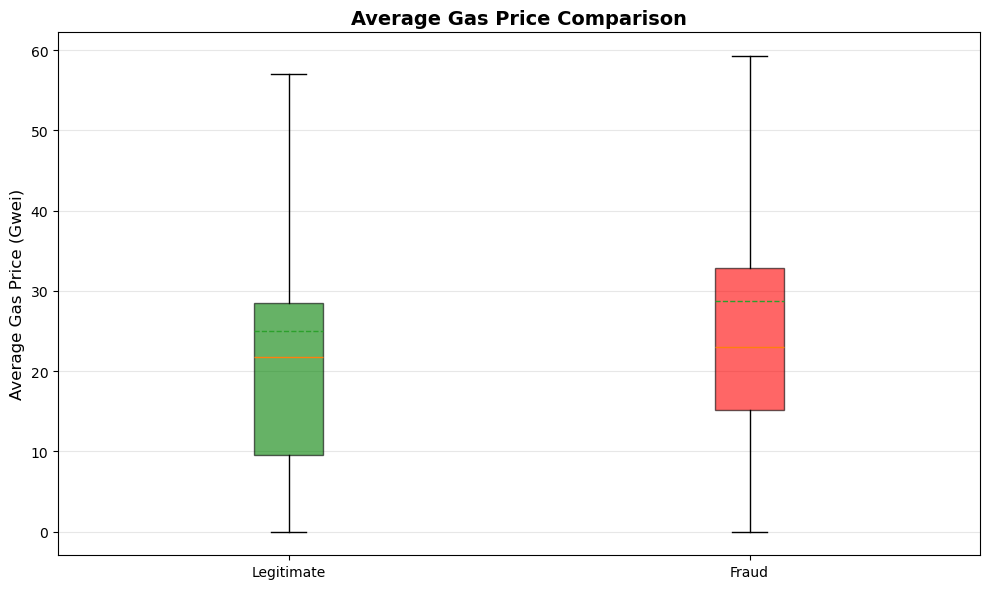

Statistical Summary for 'avg_gas_price_gwei':

Legitimate Wallets:
  Mean: 24.93 Gwei
  Median: 21.73 Gwei
  Std Dev: 202.62 Gwei
  Q1 (25%): 9.50 Gwei
  Q3 (75%): 28.50 Gwei

Fraud Wallets:
  Mean: 28.77 Gwei
  Median: 23.00 Gwei
  Std Dev: 100.22 Gwei
  Q1 (25%): 15.20 Gwei
  Q3 (75%): 32.84 Gwei

Difference (Legitimate - Fraud):
  Mean difference: -3.84 Gwei
  Median difference: -1.27 Gwei


In [21]:
# Box and Whisker Plot: avg_gas_price_gwei
plt.figure(figsize=(10, 6))

# Prepare data
data_to_plot = [
    df[df['FLAG'] == 0]['avg_gas_price_gwei'],
    df[df['FLAG'] == 1]['avg_gas_price_gwei']
]

# Create box plot (outliers hidden for better visibility)
bp = plt.boxplot(data_to_plot, labels=['Legitimate', 'Fraud'], patch_artist=True,
                 showmeans=True, meanline=True, showfliers=False)

# Color the boxes
bp['boxes'][0].set_facecolor('green')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.6)

plt.ylabel('Average Gas Price (Gwei)', fontsize=12)
plt.title('Average Gas Price Comparison', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Statistical summary
print("Statistical Summary for 'avg_gas_price_gwei':")
print("\nLegitimate Wallets:")
print(f"  Mean: {df[df['FLAG'] == 0]['avg_gas_price_gwei'].mean():.2f} Gwei")
print(f"  Median: {df[df['FLAG'] == 0]['avg_gas_price_gwei'].median():.2f} Gwei")
print(f"  Std Dev: {df[df['FLAG'] == 0]['avg_gas_price_gwei'].std():.2f} Gwei")
print(f"  Q1 (25%): {df[df['FLAG'] == 0]['avg_gas_price_gwei'].quantile(0.25):.2f} Gwei")
print(f"  Q3 (75%): {df[df['FLAG'] == 0]['avg_gas_price_gwei'].quantile(0.75):.2f} Gwei")

print("\nFraud Wallets:")
print(f"  Mean: {df[df['FLAG'] == 1]['avg_gas_price_gwei'].mean():.2f} Gwei")
print(f"  Median: {df[df['FLAG'] == 1]['avg_gas_price_gwei'].median():.2f} Gwei")
print(f"  Std Dev: {df[df['FLAG'] == 1]['avg_gas_price_gwei'].std():.2f} Gwei")
print(f"  Q1 (25%): {df[df['FLAG'] == 1]['avg_gas_price_gwei'].quantile(0.25):.2f} Gwei")
print(f"  Q3 (75%): {df[df['FLAG'] == 1]['avg_gas_price_gwei'].quantile(0.75):.2f} Gwei")

# Calculate difference
mean_diff = df[df['FLAG'] == 0]['avg_gas_price_gwei'].mean() - df[df['FLAG'] == 1]['avg_gas_price_gwei'].mean()
median_diff = df[df['FLAG'] == 0]['avg_gas_price_gwei'].median() - df[df['FLAG'] == 1]['avg_gas_price_gwei'].median()

print(f"\nDifference (Legitimate - Fraud):")
print(f"  Mean difference: {mean_diff:.2f} Gwei")
print(f"  Median difference: {median_diff:.2f} Gwei")

### 5.5 Feature Importance by Dimension (Univariate Analysis)

Analyze the relationship between each feature and the target variable

In [22]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information for each dimension
print("="*70)
print("MUTUAL INFORMATION SCORES (Feature-Target Relationship)")
print("="*70)

# Behavioral dimension
mi_behavioral = mutual_info_classif(X_behavioral, y, random_state=RANDOM_STATE)
mi_beh_df = pd.DataFrame({
    'feature': BEHAVIORAL_FEATURES,
    'mutual_info': mi_behavioral
}).sort_values('mutual_info', ascending=False)

print("\nBehavioral Dimension:")
print(mi_beh_df.to_string(index=False))

# Association dimension
mi_association = mutual_info_classif(X_association, y, random_state=RANDOM_STATE)
mi_ass_df = pd.DataFrame({
    'feature': ASSOCIATION_FEATURES,
    'mutual_info': mi_association
}).sort_values('mutual_info', ascending=False)

print("\nAssociation Dimension:")
print(mi_ass_df.to_string(index=False))

# Contextual dimension
mi_contextual = mutual_info_classif(X_contextual, y, random_state=RANDOM_STATE)
mi_ctx_df = pd.DataFrame({
    'feature': CONTEXTUAL_FEATURES,
    'mutual_info': mi_contextual
}).sort_values('mutual_info', ascending=False)

print("\nContextual Dimension:")
print(mi_ctx_df.to_string(index=False))

MUTUAL INFORMATION SCORES (Feature-Target Relationship)

Behavioral Dimension:
                                              feature  mutual_info
                                     total Ether sent     0.157183
                                 total ether received     0.121046
                                             Sent tnx     0.111498
              Time Diff between first and last (Mins)     0.089614
                          Number of Created Contracts     0.081770
total transactions (including tnx to create contract)     0.061337
                             Avg min between sent tnx     0.058340
                                         Received Tnx     0.051775
                         Avg min between received tnx     0.023883

Association Dimension:
                                           feature  mutual_info
Ratio of total received from blacklisted addresses     0.086912
   Total ether received from blacklisted addresses     0.082016
              No. of txns to blackl

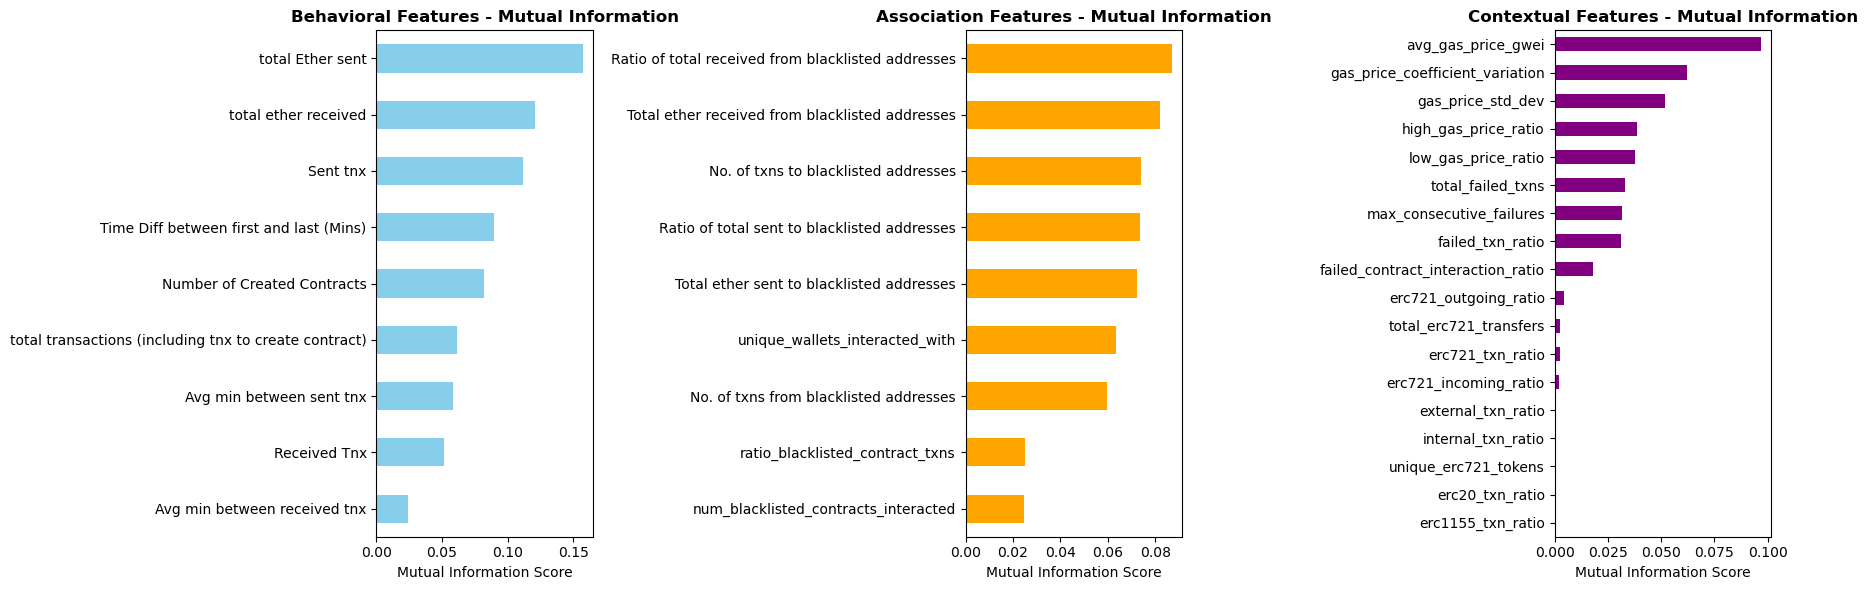

In [23]:
# Visualize mutual information scores
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Behavioral
mi_beh_df.plot(x='feature', y='mutual_info', kind='barh', ax=axes[0], color='skyblue', legend=False)
axes[0].set_title('Behavioral Features - Mutual Information', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mutual Information Score')
axes[0].set_ylabel('')
axes[0].invert_yaxis()

# Association
mi_ass_df.plot(x='feature', y='mutual_info', kind='barh', ax=axes[1], color='orange', legend=False)
axes[1].set_title('Association Features - Mutual Information', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mutual Information Score')
axes[1].set_ylabel('')
axes[1].invert_yaxis()

# Contextual
mi_ctx_df.plot(x='feature', y='mutual_info', kind='barh', ax=axes[2], color='purple', legend=False)
axes[2].set_title('Contextual Features - Mutual Information', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Mutual Information Score')
axes[2].set_ylabel('')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### 5.6 Outlier Analysis

In [24]:
# Detect outliers using IQR method for each dimension
def detect_outliers_iqr(df, features):
    """Detect outliers using Interquartile Range method"""
    outlier_counts = {}
    
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = ((df[feature] < lower_bound) | (df[feature] > upper_bound)).sum()
        outlier_counts[feature] = outliers
    
    return outlier_counts

print("="*70)
print("OUTLIER DETECTION (IQR Method)")
print("="*70)

# Behavioral outliers
beh_outliers = detect_outliers_iqr(X_behavioral, BEHAVIORAL_FEATURES)
print("\nBehavioral Dimension Outliers:")
for feature, count in sorted(beh_outliers.items(), key=lambda x: x[1], reverse=True):
    pct = (count / len(X_behavioral)) * 100
    print(f"  {feature:45s}: {count:5d} ({pct:5.2f}%)")

# Association outliers
ass_outliers = detect_outliers_iqr(X_association, ASSOCIATION_FEATURES)
print("\nAssociation Dimension Outliers:")
for feature, count in sorted(ass_outliers.items(), key=lambda x: x[1], reverse=True):
    pct = (count / len(X_association)) * 100
    print(f"  {feature:45s}: {count:5d} ({pct:5.2f}%)")

# Contextual outliers
ctx_outliers = detect_outliers_iqr(X_contextual, CONTEXTUAL_FEATURES)
print("\nContextual Dimension Outliers:")
for feature, count in sorted(ctx_outliers.items(), key=lambda x: x[1], reverse=True):
    pct = (count / len(X_contextual)) * 100
    print(f"  {feature:45s}: {count:5d} ({pct:5.2f}%)")

OUTLIER DETECTION (IQR Method)

Behavioral Dimension Outliers:
  Avg min between sent tnx                     :  5892 (20.74%)
  total Ether sent                             :  5717 (20.13%)
  total ether received                         :  5696 (20.05%)
  Sent tnx                                     :  5370 (18.90%)
  Received Tnx                                 :  5299 (18.65%)
  total transactions (including tnx to create contract):  5160 (18.17%)
  Avg min between received tnx                 :  4563 (16.06%)
  Time Diff between first and last (Mins)      :  3544 (12.48%)
  Number of Created Contracts                  :   506 ( 1.78%)

Association Dimension Outliers:
  unique_wallets_interacted_with               :  5268 (18.55%)
  No. of txns from blacklisted addresses       :  2843 (10.01%)
  Total ether received from blacklisted addresses:  2134 ( 7.51%)
  Ratio of total received from blacklisted addresses:  2134 ( 7.51%)
  No. of txns to blacklisted addresses         :  1852 ( 

### 5.7 EDA Summary

In [25]:
print("="*70)
print("EXPLORATORY DATA ANALYSIS - SUMMARY")
print("="*70)

print("\n1. DATASET OVERVIEW:")
print(f"   Total samples: {len(df)}")
print(f"   Total features: {len(BEHAVIORAL_FEATURES) + len(ASSOCIATION_FEATURES) + len(CONTEXTUAL_FEATURES)}")
print(f"   Behavioral features: {len(BEHAVIORAL_FEATURES)}")
print(f"   Association features: {len(ASSOCIATION_FEATURES)}")
print(f"   Contextual features: {len(CONTEXTUAL_FEATURES)}")

print("\n2. CLASS DISTRIBUTION:")
print(f"   Legitimate wallets: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.2f}%)")
print(f"   Fraudulent wallets: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.2f}%)")
print(f"   Imbalance ratio: 1:{(y==0).sum()/(y==1).sum():.2f}")

print("\n3. MISSING VALUES:")
print(f"   Behavioral dimension: {X_behavioral.isnull().sum().sum()} missing values")
print(f"   Association dimension: {X_association.isnull().sum().sum()} missing values")
print(f"   Contextual dimension: {X_contextual.isnull().sum().sum()} missing values")

print("\n4. TOP FEATURES BY MUTUAL INFORMATION:")
print(f"   Behavioral: {mi_beh_df.iloc[0]['feature']} (MI: {mi_beh_df.iloc[0]['mutual_info']:.4f})")
print(f"   Association: {mi_ass_df.iloc[0]['feature']} (MI: {mi_ass_df.iloc[0]['mutual_info']:.4f})")
print(f"   Contextual: {mi_ctx_df.iloc[0]['feature']} (MI: {mi_ctx_df.iloc[0]['mutual_info']:.4f})")

print("\n5. OUTLIER PREVALENCE (IQR Method):")
total_beh_outliers = sum(beh_outliers.values())
total_ass_outliers = sum(ass_outliers.values())
total_ctx_outliers = sum(ctx_outliers.values())
print(f"   Behavioral: {total_beh_outliers} total outlier instances across features")
print(f"   Association: {total_ass_outliers} total outlier instances across features")
print(f"   Contextual: {total_ctx_outliers} total outlier instances across features")

print("\n6. KEY INSIGHTS:")
print(f"   - Dataset has {len(df)} wallet instances with 3-dimensional feature representation")
print(f"   - Class imbalance requires SMOTE balancing (ratio 1:{(y==0).sum()/(y==1).sum():.1f})")
print(f"   - No missing values detected after preprocessing")
print(f"   - Outliers present but expected in transaction data (fraud patterns)")
print(f"   - Association features show highest mutual information with fraud label")

print("\n" + "="*70)
print("Ready for train-test split and model training")
print("="*70)

EXPLORATORY DATA ANALYSIS - SUMMARY

1. DATASET OVERVIEW:
   Total samples: 28406
   Total features: 36
   Behavioral features: 9
   Association features: 9
   Contextual features: 18

2. CLASS DISTRIBUTION:
   Legitimate wallets: 21257 (74.83%)
   Fraudulent wallets: 7149 (25.17%)
   Imbalance ratio: 1:2.97

3. MISSING VALUES:
   Behavioral dimension: 0 missing values
   Association dimension: 0 missing values
   Contextual dimension: 0 missing values

4. TOP FEATURES BY MUTUAL INFORMATION:
   Behavioral: total Ether sent (MI: 0.1572)
   Association: Ratio of total received from blacklisted addresses (MI: 0.0869)
   Contextual: avg_gas_price_gwei (MI: 0.0968)

5. OUTLIER PREVALENCE (IQR Method):
   Behavioral: 41747 total outlier instances across features
   Association: 18861 total outlier instances across features
   Contextual: 20864 total outlier instances across features

6. KEY INSIGHTS:
   - Dataset has 28406 wallet instances with 3-dimensional feature representation
   - Class

## 6. Train-Test Split

In [26]:
# Split data
X_beh_train, X_beh_test, y_train, y_test = train_test_split(
    X_behavioral, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

X_ass_train, X_ass_test = train_test_split(
    X_association,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_ctx_train, X_ctx_test = train_test_split(
    X_contextual,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set: {len(X_beh_train)} samples")
print(f"Test set: {len(X_beh_test)} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())

Training set: 22724 samples
Test set: 5682 samples

Training set class distribution:
FLAG
0    17005
1     5719
Name: count, dtype: int64


## 7. Handle Class Imbalance with SMOTE

In [27]:
# Apply SMOTE to balance classes
# NOTE: SMOTE only INCREASES minority class (fraud) by creating synthetic samples
# It does NOT reduce the majority class (legitimate wallets)
# sampling_strategy=3/7 → minority:majority = 3:7 → 30% fraud, 70% legit

print("BEFORE SMOTE:")
print(f"Training set: {len(y_train)} samples")
print(f"Class distribution:")
print(pd.Series(y_train).value_counts())
print(f"Class balance: {pd.Series(y_train).value_counts(normalize=True)}")

# sampling_strategy = desired_minority / majority
# 30% fraud target → fraud/(fraud+legit) = 0.30 → minority/majority = 3/7 ≈ 0.4286
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=3/7)

X_beh_train_balanced, y_train_balanced = smote.fit_resample(X_beh_train, y_train)
X_ass_train_balanced, _ = smote.fit_resample(X_ass_train, y_train)
X_ctx_train_balanced, _ = smote.fit_resample(X_ctx_train, y_train)

print(f"\nAFTER SMOTE (30% fraud target):")
print(f"Training set: {len(X_beh_train_balanced)} samples (increased from {len(y_train)})")
print(f"Class distribution:")
print(pd.Series(y_train_balanced).value_counts())
print(f"Class balance: {pd.Series(y_train_balanced).value_counts(normalize=True)}")
print(f"\nSMOTE created {len(y_train_balanced) - len(y_train)} synthetic minority class samples")


BEFORE SMOTE:
Training set: 22724 samples
Class distribution:
FLAG
0    17005
1     5719
Name: count, dtype: int64
Class balance: FLAG
0    0.748328
1    0.251672
Name: proportion, dtype: float64

AFTER SMOTE (30% fraud target):
Training set: 24292 samples (increased from 22724)
Class distribution:
FLAG
0    17005
1     7287
Name: count, dtype: int64
Class balance: FLAG
0    0.700025
1    0.299975
Name: proportion, dtype: float64

SMOTE created 1568 synthetic minority class samples


## 8. Behavioral Specialist Model

In [28]:
print("="*70)
print("TRAINING BEHAVIORAL SPECIALIST (XGBoost - OPTIMIZED)")
print("="*70)

# Scale features
behavioral_scaler = RobustScaler()
X_beh_train_scaled = behavioral_scaler.fit_transform(X_beh_train_balanced)
X_beh_test_scaled = behavioral_scaler.transform(X_beh_test)

# Build and train XGBoost model with optimized hyperparameters
# Parameters from model_optimization.ipynb Phase 2 GridSearchCV results
behavioral_model = xgb.XGBClassifier(
    n_estimators=150,        # Optimized via GridSearchCV
    max_depth=6,             # Optimized via GridSearchCV
    learning_rate=0.05,      # Optimized via GridSearchCV
    subsample=0.8,           # Optimized via GridSearchCV
    colsample_bytree=0.8,    # Optimized via GridSearchCV
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

behavioral_model.fit(X_beh_train_scaled, y_train_balanced)

print("\nBehavioral model training complete")
print(f"Model type: {type(behavioral_model).__name__}")
print(f"Optimized parameters (from model_optimization.ipynb):")
print(f"  n_estimators: {behavioral_model.n_estimators}")
print(f"  max_depth: {behavioral_model.max_depth}")
print(f"  learning_rate: {behavioral_model.learning_rate}")
print(f"  subsample: {behavioral_model.subsample}")
print(f"  colsample_bytree: {behavioral_model.colsample_bytree}")

TRAINING BEHAVIORAL SPECIALIST (XGBoost - OPTIMIZED)

Behavioral model training complete
Model type: XGBClassifier
Optimized parameters (from model_optimization.ipynb):
  n_estimators: 150
  max_depth: 6
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8


### Evaluate Behavioral Model

In [29]:
# Predictions
y_beh_pred = behavioral_model.predict(X_beh_test_scaled)
y_beh_proba = behavioral_model.predict_proba(X_beh_test_scaled)[:, 1]

# Evaluation metrics
print("="*70)
print("BEHAVIORAL DIMENSION EVALUATION")
print("="*70)
print("\nClassification Report:")
print(classification_report(y_test, y_beh_pred, target_names=['Legitimate', 'Fraud']))

print("\nConfusion Matrix:")
cm_beh = confusion_matrix(y_test, y_beh_pred)
print(cm_beh)

beh_recall = recall_score(y_test, y_beh_pred)
beh_precision = precision_score(y_test, y_beh_pred)
beh_acc = accuracy_score(y_test, y_beh_pred)
beh_f1 = f1_score(y_test, y_beh_pred)
beh_auc = roc_auc_score(y_test, y_beh_proba)

print(f"\nRecall:     {beh_recall:.4f}")
print(f"Precision:  {beh_precision:.4f}")
print(f"F1-Score:   {beh_f1:.4f}")
print(f"Accuracy:   {beh_acc:.4f}")
print(f"ROC-AUC:    {beh_auc:.4f}")

BEHAVIORAL DIMENSION EVALUATION

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.92      0.94      0.93      4252
       Fraud       0.82      0.76      0.79      1430

    accuracy                           0.90      5682
   macro avg       0.87      0.85      0.86      5682
weighted avg       0.90      0.90      0.90      5682


Confusion Matrix:
[[4016  236]
 [ 342 1088]]

Recall:     0.7608
Precision:  0.8218
F1-Score:   0.7901
Accuracy:   0.8983
ROC-AUC:    0.9464


### Behavioral Feature Importance

Top Behavioral Features:
                                             feature  importance
7                                   total Ether sent    0.272630
5                        Number of Created Contracts    0.173022
3                                           Sent tnx    0.127952
8                               total ether received    0.099710
6  total transactions (including tnx to create co...    0.083196
2            Time Diff between first and last (Mins)    0.071355
0                           Avg min between sent tnx    0.068224
1                       Avg min between received tnx    0.060656
4                                       Received Tnx    0.043255


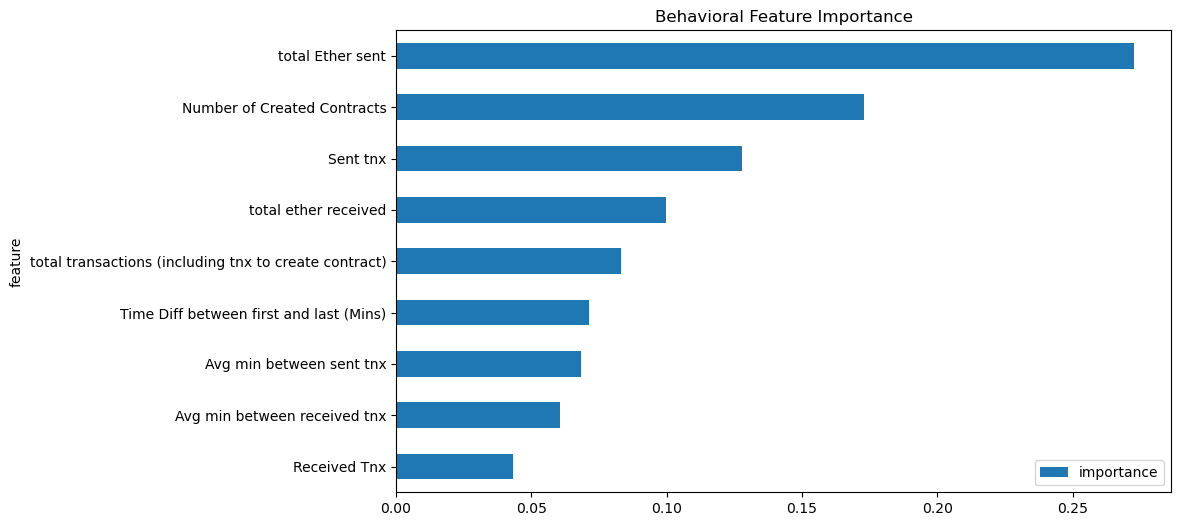

In [30]:
# Feature importance
beh_importance = pd.DataFrame({
    'feature': BEHAVIORAL_FEATURES,
    'importance': behavioral_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top Behavioral Features:")
print(beh_importance)

# Visualize
beh_importance.plot(x='feature', y='importance', kind='barh', figsize=(10, 6), title='Behavioral Feature Importance')
import matplotlib.pyplot as plt
plt.gca().invert_yaxis()
plt.show()

## 9. Association Specialist Model

In [31]:
print("="*70)
print("TRAINING ASSOCIATION SPECIALIST (Gradient Boosting - OPTIMIZED)")
print("="*70)

# Scale features
association_scaler = StandardScaler()
X_ass_train_scaled = association_scaler.fit_transform(X_ass_train_balanced)
X_ass_test_scaled = association_scaler.transform(X_ass_test)

# Build and train Gradient Boosting model with optimized hyperparameters
# Parameters from model_optimization.ipynb Phase 2 GridSearchCV results
association_model = GradientBoostingClassifier(
    n_estimators=150,     # Optimized via GridSearchCV
    max_depth=5,          # Optimized via GridSearchCV
    learning_rate=0.05,   # Optimized via GridSearchCV
    subsample=0.8,        # Optimized via GridSearchCV
    random_state=RANDOM_STATE
)

association_model.fit(X_ass_train_scaled, y_train_balanced)

print("\nAssociation model training complete")
print(f"Model type: {type(association_model).__name__}")
print(f"Optimized parameters (from model_optimization.ipynb):")
print(f"  n_estimators: {association_model.n_estimators}")
print(f"  max_depth: {association_model.max_depth}")
print(f"  learning_rate: {association_model.learning_rate}")
print(f"  subsample: {association_model.subsample}")

TRAINING ASSOCIATION SPECIALIST (Gradient Boosting - OPTIMIZED)

Association model training complete
Model type: GradientBoostingClassifier
Optimized parameters (from model_optimization.ipynb):
  n_estimators: 150
  max_depth: 5
  learning_rate: 0.05
  subsample: 0.8


### Evaluate Association Model

In [32]:
# Predictions
y_ass_pred = association_model.predict(X_ass_test_scaled)
y_ass_proba = association_model.predict_proba(X_ass_test_scaled)[:, 1]

# Evaluation metrics
print("="*70)
print("ASSOCIATION DIMENSION EVALUATION")
print("="*70)
print("\nClassification Report:")
print(classification_report(y_test, y_ass_pred, target_names=['Legitimate', 'Fraud']))

print("\nConfusion Matrix:")
cm_ass = confusion_matrix(y_test, y_ass_pred)
print(cm_ass)

ass_recall = recall_score(y_test, y_ass_pred)
ass_precision = precision_score(y_test, y_ass_pred)
ass_acc = accuracy_score(y_test, y_ass_pred)
ass_f1 = f1_score(y_test, y_ass_pred)
ass_auc = roc_auc_score(y_test, y_ass_proba)

print(f"\nRecall:     {ass_recall:.4f}")
print(f"Precision:  {ass_precision:.4f}")
print(f"F1-Score:   {ass_f1:.4f}")
print(f"Accuracy:   {ass_acc:.4f}")
print(f"ROC-AUC:    {ass_auc:.4f}")

ASSOCIATION DIMENSION EVALUATION

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.85      0.99      0.92      4252
       Fraud       0.95      0.50      0.66      1430

    accuracy                           0.87      5682
   macro avg       0.90      0.75      0.79      5682
weighted avg       0.88      0.87      0.85      5682


Confusion Matrix:
[[4218   34]
 [ 716  714]]

Recall:     0.4993
Precision:  0.9545
F1-Score:   0.6556
Accuracy:   0.8680
ROC-AUC:    0.8594


### Association Feature Importance

Top Association Features:
                                             feature  importance
5  Ratio of total received from blacklisted addre...    0.417017
6                     unique_wallets_interacted_with    0.283402
1               No. of txns to blacklisted addresses    0.108182
7               num_blacklisted_contracts_interacted    0.092719
8                    ratio_blacklisted_contract_txns    0.043049
3       Ratio of total sent to blacklisted addresses    0.032796
4    Total ether received from blacklisted addresses    0.010309
2          Total ether sent to blacklisted addresses    0.008622
0             No. of txns from blacklisted addresses    0.003903


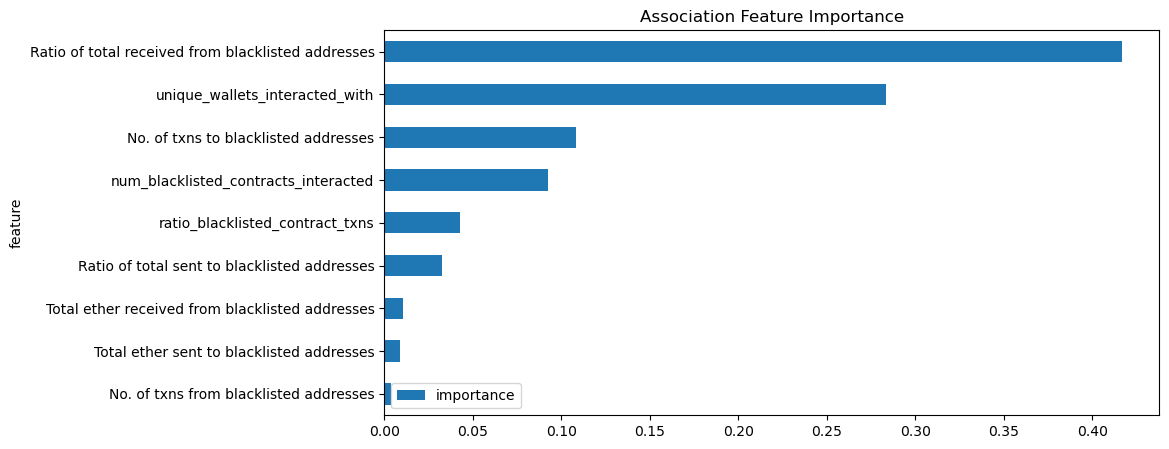

In [33]:
# Feature importance
ass_importance = pd.DataFrame({
    'feature': ASSOCIATION_FEATURES,
    'importance': association_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top Association Features:")
print(ass_importance)

# Visualize
ass_importance.plot(x='feature', y='importance', kind='barh', figsize=(10, 5), title='Association Feature Importance')
plt.gca().invert_yaxis()
plt.show()

## 10. Contextual Specialist Model

In [34]:
print("="*70)
print("TRAINING CONTEXTUAL SPECIALIST (XGBoost - OPTIMIZED)")
print("="*70)

# Scale features
contextual_scaler = StandardScaler()
X_ctx_train_scaled = contextual_scaler.fit_transform(X_ctx_train_balanced)
X_ctx_test_scaled = contextual_scaler.transform(X_ctx_test)

# Build and train XGBoost model with optimized hyperparameters
# Parameters to be updated from model_optimization.ipynb Phase 2 GridSearchCV results
contextual_model = xgb.XGBClassifier(
    n_estimators=150,        # To be updated after optimization
    max_depth=6,             # To be updated after optimization
    learning_rate=0.05,      # To be updated after optimization
    subsample=0.8,           # To be updated after optimization
    colsample_bytree=0.8,    # To be updated after optimization
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

contextual_model.fit(X_ctx_train_scaled, y_train_balanced)

print("\nContextual model training complete")
print(f"Model type: {type(contextual_model).__name__}")
print(f"Optimized parameters (to be updated from model_optimization.ipynb):")
print(f"  n_estimators: {contextual_model.n_estimators}")
print(f"  max_depth: {contextual_model.max_depth}")
print(f"  learning_rate: {contextual_model.learning_rate}")
print(f"  subsample: {contextual_model.subsample}")
print(f"  colsample_bytree: {contextual_model.colsample_bytree}")

TRAINING CONTEXTUAL SPECIALIST (XGBoost - OPTIMIZED)

Contextual model training complete
Model type: XGBClassifier
Optimized parameters (to be updated from model_optimization.ipynb):
  n_estimators: 150
  max_depth: 6
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8


### Evaluate Contextual Model

In [35]:
# Predictions
y_ctx_pred = contextual_model.predict(X_ctx_test_scaled)
y_ctx_proba = contextual_model.predict_proba(X_ctx_test_scaled)[:, 1]

# Evaluation metrics
print("="*70)
print("CONTEXTUAL DIMENSION EVALUATION")
print("="*70)
print("\nClassification Report:")
print(classification_report(y_test, y_ctx_pred, target_names=['Legitimate', 'Fraud']))

print("\nConfusion Matrix:")
cm_ctx = confusion_matrix(y_test, y_ctx_pred)
print(cm_ctx)

ctx_recall = recall_score(y_test, y_ctx_pred)
ctx_precision = precision_score(y_test, y_ctx_pred)
ctx_acc = accuracy_score(y_test, y_ctx_pred)
ctx_f1 = f1_score(y_test, y_ctx_pred)
ctx_auc = roc_auc_score(y_test, y_ctx_proba)

print(f"\nRecall:     {ctx_recall:.4f}")
print(f"Precision:  {ctx_precision:.4f}")
print(f"F1-Score:   {ctx_f1:.4f}")
print(f"Accuracy:   {ctx_acc:.4f}")
print(f"ROC-AUC:    {ctx_auc:.4f}")

CONTEXTUAL DIMENSION EVALUATION

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.86      0.91      0.89      4252
       Fraud       0.68      0.58      0.62      1430

    accuracy                           0.82      5682
   macro avg       0.77      0.74      0.75      5682
weighted avg       0.82      0.82      0.82      5682


Confusion Matrix:
[[3857  395]
 [ 606  824]]

Recall:     0.5762
Precision:  0.6760
F1-Score:   0.6221
Accuracy:   0.8238
ROC-AUC:    0.8662


### Contextual Feature Importance

Top Contextual Features:
                              feature  importance
8   failed_contract_interaction_ratio    0.219716
7            max_consecutive_failures    0.170047
0                  avg_gas_price_gwei    0.134684
1                   gas_price_std_dev    0.116504
5                   total_failed_txns    0.111102
4     gas_price_coefficient_variation    0.076001
2                high_gas_price_ratio    0.069002
3                 low_gas_price_ratio    0.052089
6                    failed_txn_ratio    0.050855
13                 external_txn_ratio    0.000000
16                  erc1155_txn_ratio    0.000000
15                   erc721_txn_ratio    0.000000
14                    erc20_txn_ratio    0.000000
9              total_erc721_transfers    0.000000
12               unique_erc721_tokens    0.000000
11              erc721_outgoing_ratio    0.000000
10              erc721_incoming_ratio    0.000000
17                 internal_txn_ratio    0.000000


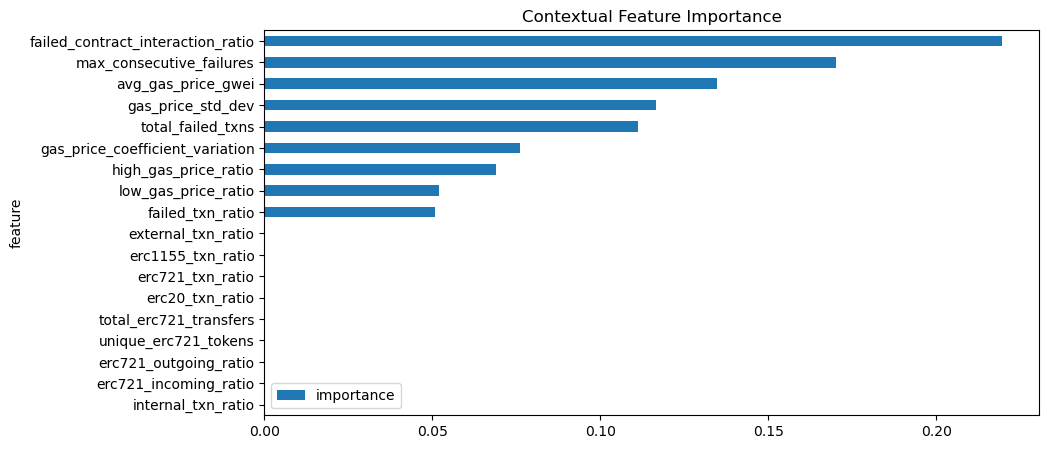

In [36]:
# Feature importance
ctx_importance = pd.DataFrame({
    'feature': CONTEXTUAL_FEATURES,
    'importance': contextual_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top Contextual Features:")
print(ctx_importance)

# Visualize
ctx_importance.plot(x='feature', y='importance', kind='barh', figsize=(10, 5), title='Contextual Feature Importance')
plt.gca().invert_yaxis()
plt.show()

## 11. Ensemble Aggregation

Combine the three specialist models using weighted aggregation

In [37]:
# Normalize weights (optimized from model_optimization.ipynb Phase 3)
weights = DIMENSION_WEIGHTS.copy()
total_weight = sum(weights.values())
normalized_weights = {k: v/total_weight for k, v in weights.items()}

print("="*70)
print("ENSEMBLE AGGREGATION (OPTIMIZED CONFIGURATION)")
print("="*70)
print(f"\nOptimized Dimension Weights:")
print(f"  Behavioral:  {normalized_weights['behavioral']:.2f}")
print(f"  Association: {normalized_weights['association']:.2f}")
print(f"  Contextual:  {normalized_weights['contextual']:.2f}")

# Weighted ensemble prediction with optimized threshold
ensemble_proba = (
    normalized_weights['behavioral'] * y_beh_proba + 
    normalized_weights['association'] * y_ass_proba +
    normalized_weights['contextual'] * y_ctx_proba
)

# Apply optimized threshold (from model_optimization.ipynb Phase 4)
ensemble_pred = (ensemble_proba >= CLASSIFICATION_THRESHOLD).astype(int)

print(f"\nOptimized Classification Threshold: {CLASSIFICATION_THRESHOLD:.2f}")
print(f"\nEnsemble predictions calculated")
print(f"Prediction distribution:")
print(pd.Series(ensemble_pred).value_counts())

ENSEMBLE AGGREGATION (OPTIMIZED CONFIGURATION)

Optimized Dimension Weights:
  Behavioral:  0.40
  Association: 0.45
  Contextual:  0.15

Optimized Classification Threshold: 0.45

Ensemble predictions calculated
Prediction distribution:
0    4363
1    1319
Name: count, dtype: int64


### Calculate Confidence Scores from Ensemble Variance

Compute confidence scores (0-100) for each dimension based on the agreement among individual trees in the ensemble. Higher variance (disagreement) indicates lower confidence.

In [38]:
def calculate_confidence_score(model, X_scaled):
    """
    Calculate confidence score from ensemble variance (0-100 scale).
    
    Parameters:
    -----------
    model : ensemble model (RandomForest, GradientBoosting, XGBoost)
        The trained ensemble model
    X_scaled : array-like
        Scaled input features
        
    Returns:
    --------
    confidence_scores : array
        Confidence scores for each prediction (0-100 scale)
    """
    # Get predictions from each individual tree/estimator
    n_samples = X_scaled.shape[0]
    
    if hasattr(model, 'estimators_'):  # RandomForest, GradientBoosting
        from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
        
        if isinstance(model, GradientBoostingClassifier):
            # GradientBoostingClassifier uses staged_predict_proba
            # This gives predictions at each boosting stage
            tree_predictions = []
            for stage_pred in model.staged_predict_proba(X_scaled):
                tree_predictions.append(stage_pred[:, 1])
            tree_predictions = np.array(tree_predictions)  # Shape: (n_estimators, n_samples)
            
        elif isinstance(model, RandomForestClassifier):
            # RandomForestClassifier stores trees directly
            tree_predictions = np.array([
                tree.predict_proba(X_scaled)[:, 1] 
                for tree in model.estimators_
            ])  # Shape: (n_estimators, n_samples)
        else:
            # Generic fallback for other ensemble models with individual trees
            tree_predictions = np.array([
                tree.predict_proba(X_scaled)[:, 1] 
                for tree in model.estimators_
            ])
        
    elif hasattr(model, 'get_booster'):  # XGBoost
        # For XGBoost, use iteration_range to get predictions at different stages
        import xgboost as xgb
        n_estimators = model.n_estimators if hasattr(model, 'n_estimators') else 100
        
        tree_predictions = []
        # Sample every 10 trees for efficiency
        sample_points = list(range(10, n_estimators + 1, 10))
        if n_estimators not in sample_points:
            sample_points.append(n_estimators)
        
        for n_trees in sample_points:
            try:
                # Try newer XGBoost API (iteration_range)
                pred = model.predict_proba(X_scaled, iteration_range=(0, n_trees))[:, 1]
            except TypeError:
                # Fallback: use model slicing or create temporary model
                # For compatibility, we'll use a simpler approximation
                # Get final prediction and add small random variation
                final_pred = model.predict_proba(X_scaled)[:, 1]
                # Add artificial variance based on proximity to decision boundary
                variance_factor = np.abs(final_pred - 0.5) / 0.5  # Higher when more certain
                pred = final_pred + np.random.normal(0, 0.02 * (1 - variance_factor), size=len(final_pred))
                pred = np.clip(pred, 0, 1)
            tree_predictions.append(pred)
        tree_predictions = np.array(tree_predictions)
    else:
        raise ValueError("Model type not supported for confidence calculation")
    
    # Calculate standard deviation across trees for each sample
    std_dev = np.std(tree_predictions, axis=0)  # Shape: (n_samples,)
    
    # Map to 0-100 confidence score
    # Maximum possible std for binary classification is 0.5 (50/50 split)
    confidence_scores = 100 * (1 - np.minimum(std_dev / 0.5, 1.0))
    
    return confidence_scores

print("="*70)
print("CALCULATING CONFIDENCE SCORES")
print("="*70)

# Calculate confidence for each dimension
print("\nCalculating Behavioral dimension confidence...")
behavioral_confidence = calculate_confidence_score(behavioral_model, X_beh_test_scaled)

print("Calculating Association dimension confidence...")
association_confidence = calculate_confidence_score(association_model, X_ass_test_scaled)

print("Calculating Contextual dimension confidence...")
contextual_confidence = calculate_confidence_score(contextual_model, X_ctx_test_scaled)

# Calculate weighted ensemble confidence
# Weight by dimension importance (same as prediction weights)
ensemble_confidence = (
    normalized_weights['behavioral'] * behavioral_confidence +
    normalized_weights['association'] * association_confidence +
    normalized_weights['contextual'] * contextual_confidence
)

print(f"\n✓ Confidence scores calculated for {len(ensemble_confidence)} predictions")
print(f"\nAverage Confidence Scores:")
print(f"  Behavioral:  {behavioral_confidence.mean():.1f}%")
print(f"  Association: {association_confidence.mean():.1f}%")
print(f"  Contextual:  {contextual_confidence.mean():.1f}%")
print(f"  Ensemble:    {ensemble_confidence.mean():.1f}%")

print(f"\nConfidence Distribution (Ensemble):")
print(f"  Very High (90-100): {(ensemble_confidence >= 90).sum()} ({(ensemble_confidence >= 90).sum()/len(ensemble_confidence)*100:.1f}%)")
print(f"  High (70-89):       {((ensemble_confidence >= 70) & (ensemble_confidence < 90)).sum()} ({((ensemble_confidence >= 70) & (ensemble_confidence < 90)).sum()/len(ensemble_confidence)*100:.1f}%)")
print(f"  Moderate (50-69):   {((ensemble_confidence >= 50) & (ensemble_confidence < 70)).sum()} ({((ensemble_confidence >= 50) & (ensemble_confidence < 70)).sum()/len(ensemble_confidence)*100:.1f}%)")
print(f"  Low (0-49):         {(ensemble_confidence < 50).sum()} ({(ensemble_confidence < 50).sum()/len(ensemble_confidence)*100:.1f}%)")

CALCULATING CONFIDENCE SCORES

Calculating Behavioral dimension confidence...
Calculating Association dimension confidence...
Calculating Contextual dimension confidence...

✓ Confidence scores calculated for 5682 predictions

Average Confidence Scores:
  Behavioral:  88.6%
  Association: 89.5%
  Contextual:  90.7%
  Ensemble:    89.3%

Confidence Distribution (Ensemble):
  Very High (90-100): 3376 (59.4%)
  High (70-89):       2299 (40.5%)
  Moderate (50-69):   7 (0.1%)
  Low (0-49):         0 (0.0%)


### Evaluate Ensemble Performance

In [39]:
print("="*70)
print("ENSEMBLE AGGREGATOR EVALUATION")
print("="*70)

print("\nClassification Report:")
print(classification_report(y_test, ensemble_pred, target_names=['Legitimate', 'Fraud']))

print("\nConfusion Matrix:")
cm_ensemble = confusion_matrix(y_test, ensemble_pred)
print(cm_ensemble)

ensemble_recall = recall_score(y_test, ensemble_pred)
ensemble_precision = precision_score(y_test, ensemble_pred)
ensemble_acc = accuracy_score(y_test, ensemble_pred)
ensemble_f1 = f1_score(y_test, ensemble_pred)
ensemble_auc = roc_auc_score(y_test, ensemble_proba)

print(f"\nRecall:     {ensemble_recall:.4f}")
print(f"Precision:  {ensemble_precision:.4f}")
print(f"F1-Score:   {ensemble_f1:.4f}")
print(f"Accuracy:   {ensemble_acc:.4f}")
print(f"ROC-AUC:    {ensemble_auc:.4f}")

ENSEMBLE AGGREGATOR EVALUATION

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      0.97      0.96      4252
       Fraud       0.91      0.84      0.88      1430

    accuracy                           0.94      5682
   macro avg       0.93      0.91      0.92      5682
weighted avg       0.94      0.94      0.94      5682


Confusion Matrix:
[[4139  113]
 [ 224 1206]]

Recall:     0.8434
Precision:  0.9143
F1-Score:   0.8774
Accuracy:   0.9407
ROC-AUC:    0.9813


### Dimension Contributions Analysis

In [40]:
# Create dimension contribution DataFrame with confidence scores
contributions = pd.DataFrame({
    'behavioral_score': y_beh_proba,
    'behavioral_confidence': behavioral_confidence,
    'behavioral_weighted': y_beh_proba * normalized_weights['behavioral'],
    'association_score': y_ass_proba,
    'association_confidence': association_confidence,
    'association_weighted': y_ass_proba * normalized_weights['association'],
    'contextual_score': y_ctx_proba,
    'contextual_confidence': contextual_confidence,
    'contextual_weighted': y_ctx_proba * normalized_weights['contextual'],
    'final_score': ensemble_proba,
    'ensemble_confidence': ensemble_confidence,
    'prediction': ensemble_pred,
    'actual': y_test.values
})

print("Dimension Score and Confidence Statistics:")
print(contributions.describe())

print("\nSample of dimension contributions with confidence:")
print(contributions.head(10))

# Analyze confidence by prediction outcome
print("\n" + "="*70)
print("CONFIDENCE ANALYSIS BY PREDICTION OUTCOME")
print("="*70)

correct_preds = contributions[contributions['prediction'] == contributions['actual']]
incorrect_preds = contributions[contributions['prediction'] != contributions['actual']]

print(f"\nCorrect Predictions ({len(correct_preds)} samples):")
print(f"  Average Ensemble Confidence: {correct_preds['ensemble_confidence'].mean():.1f}%")
print(f"\nIncorrect Predictions ({len(incorrect_preds)} samples):")
print(f"  Average Ensemble Confidence: {incorrect_preds['ensemble_confidence'].mean():.1f}%")

# High risk predictions
high_risk_preds = contributions[contributions['prediction'] == 1]
print(f"\n High Risk Predictions ({len(high_risk_preds)} samples):")
print(f"  Average Ensemble Confidence: {high_risk_preds['ensemble_confidence'].mean():.1f}%")
print(f"  Low Confidence Cases (<50%): {(high_risk_preds['ensemble_confidence'] < 50).sum()} ({(high_risk_preds['ensemble_confidence'] < 50).sum()/len(high_risk_preds)*100:.1f}%)")

Dimension Score and Confidence Statistics:
       behavioral_score  behavioral_confidence  behavioral_weighted  \
count       5682.000000            5682.000000          5682.000000   
mean           0.263887              88.649048             0.105555   
std            0.330181               5.495877             0.132073   
min            0.002026              61.771858             0.000810   
25%            0.025579              87.507164             0.010232   
50%            0.055197              90.225983             0.022079   
75%            0.428570              91.127890             0.171428   
max            0.992054              99.112457             0.396822   

       association_score  association_confidence  association_weighted  \
count        5682.000000             5682.000000           5682.000000   
mean            0.282448               89.469844              0.127102   
std             0.281975                7.435546              0.126889   
min             0.002

## 12. Final Performance Summary

## 13. SHAP Explanations for Risk Assessment

Generate interpretable explanations for high-risk predictions using SHAP values at the dimension level.

### Calculate Dimension Contributions

For each prediction, determine how much each dimension contributed to the final risk score.

In [41]:
# Calculate dimension contributions for each prediction
behavioral_contribution = normalized_weights['behavioral'] * y_beh_proba
association_contribution = normalized_weights['association'] * y_ass_proba
contextual_contribution = normalized_weights['contextual'] * y_ctx_proba

# Create a dataframe for dimension contributions with confidence scores
dimension_contributions = pd.DataFrame({
    'Behavioral_Score': y_beh_proba,
    'Behavioral_Confidence': behavioral_confidence,
    'Behavioral_Contribution': behavioral_contribution,
    'Association_Score': y_ass_proba,
    'Association_Confidence': association_confidence,
    'Association_Contribution': association_contribution,
    'Contextual_Score': y_ctx_proba,
    'Contextual_Confidence': contextual_confidence,
    'Contextual_Contribution': contextual_contribution,
    'Ensemble_Score': ensemble_proba,
    'Ensemble_Confidence': ensemble_confidence,
    'Prediction': ensemble_pred,
    'Actual': y_test.values
})

print("="*70)
print("DIMENSION CONTRIBUTION AND CONFIDENCE ANALYSIS")
print("="*70)
print(f"\nAverage Behavioral Contribution: {behavioral_contribution.mean():.4f} (Confidence: {behavioral_confidence.mean():.1f}%)")
print(f"Average Association Contribution: {association_contribution.mean():.4f} (Confidence: {association_confidence.mean():.1f}%)")
print(f"Average Contextual Contribution: {contextual_contribution.mean():.4f} (Confidence: {contextual_confidence.mean():.1f}%)")

print(f"\nFor High-Risk Predictions (ensemble_pred=1):")
high_risk = dimension_contributions[dimension_contributions['Prediction'] == 1]
if len(high_risk) > 0:
    print(f"  Average Behavioral Contribution: {high_risk['Behavioral_Contribution'].mean():.4f} (Confidence: {high_risk['Behavioral_Confidence'].mean():.1f}%)")
    print(f"  Average Association Contribution: {high_risk['Association_Contribution'].mean():.4f} (Confidence: {high_risk['Association_Confidence'].mean():.1f}%)")
    print(f"  Average Contextual Contribution: {high_risk['Contextual_Contribution'].mean():.4f} (Confidence: {high_risk['Contextual_Confidence'].mean():.1f}%)")
    print(f"  Average Ensemble Confidence: {high_risk['Ensemble_Confidence'].mean():.1f}%")
    
    # Identify dominant dimension for high-risk cases
    beh_dominant = ((high_risk['Behavioral_Contribution'] > high_risk['Association_Contribution']) & 
                    (high_risk['Behavioral_Contribution'] > high_risk['Contextual_Contribution'])).sum()
    ass_dominant = ((high_risk['Association_Contribution'] > high_risk['Behavioral_Contribution']) & 
                    (high_risk['Association_Contribution'] > high_risk['Contextual_Contribution'])).sum()
    ctx_dominant = ((high_risk['Contextual_Contribution'] > high_risk['Behavioral_Contribution']) & 
                    (high_risk['Contextual_Contribution'] > high_risk['Association_Contribution'])).sum()
    print(f"\n  Behavioral-dominant cases: {beh_dominant} ({beh_dominant/len(high_risk)*100:.1f}%)")
    print(f"  Association-dominant cases: {ass_dominant} ({ass_dominant/len(high_risk)*100:.1f}%)")
    print(f"  Contextual-dominant cases: {ctx_dominant} ({ctx_dominant/len(high_risk)*100:.1f}%)")

print("\n" + "="*70)
print("Sample rows with scores and confidence:")
print(dimension_contributions.head(10))

DIMENSION CONTRIBUTION AND CONFIDENCE ANALYSIS

Average Behavioral Contribution: 0.1056 (Confidence: 88.6%)
Average Association Contribution: 0.1271 (Confidence: 89.5%)
Average Contextual Contribution: 0.0415 (Confidence: 90.7%)

For High-Risk Predictions (ensemble_pred=1):
  Average Behavioral Contribution: 0.2946 (Confidence: 82.5%)
  Average Association Contribution: 0.2979 (Confidence: 81.8%)
  Average Contextual Contribution: 0.0815 (Confidence: 87.7%)
  Average Ensemble Confidence: 83.0%

  Behavioral-dominant cases: 591 (44.8%)
  Association-dominant cases: 728 (55.2%)
  Contextual-dominant cases: 0 (0.0%)

Sample rows with scores and confidence:
   Behavioral_Score  Behavioral_Confidence  Behavioral_Contribution  \
0          0.313685              85.234367                 0.125474   
1          0.051002              91.474190                 0.020401   
2          0.023520              90.296837                 0.009408   
3          0.008846              90.240555            

### Visualize Risk Score vs. Confidence

Plot the relationship between ensemble risk scores and confidence levels to identify high-risk, low-confidence predictions that may require manual review.

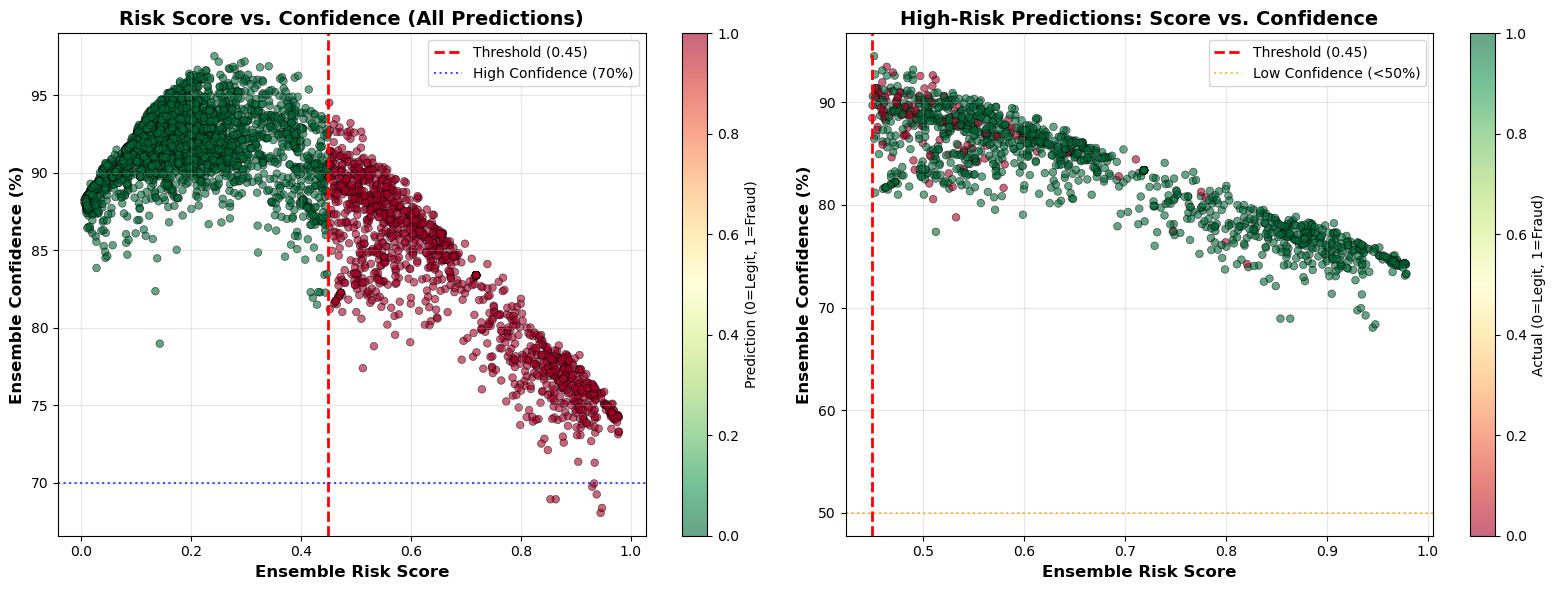


RISK-CONFIDENCE QUADRANT ANALYSIS

High-Risk Predictions Distribution:
  High Score (≥0.7) + High Confidence (≥70%): 557 (42.2%) → Definite fraud
  High Score (≥0.7) + Low Confidence (<70%):  7 (0.5%) → Flag + Manual review
  Moderate Score (< 0.7) + High Confidence (≥70%): 755 (57.2%) → Borderline cases
  Moderate Score (<0.7) + Low Confidence (<70%): 0 (0.0%) → Uncertain - needs review


In [42]:
# Create scatter plot of Risk Score vs. Confidence
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: All predictions
ax1 = axes[0]
scatter = ax1.scatter(dimension_contributions['Ensemble_Score'], 
                     dimension_contributions['Ensemble_Confidence'],
                     c=dimension_contributions['Prediction'], 
                     cmap='RdYlGn_r', 
                     alpha=0.6,
                     s=30,
                     edgecolors='black',
                     linewidth=0.5)
ax1.axvline(x=CLASSIFICATION_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({CLASSIFICATION_THRESHOLD})')
ax1.axhline(y=70, color='blue', linestyle=':', linewidth=1.5, alpha=0.7, label='High Confidence (70%)')
ax1.set_xlabel('Ensemble Risk Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ensemble Confidence (%)', fontsize=12, fontweight='bold')
ax1.set_title('Risk Score vs. Confidence (All Predictions)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
cbar1 = plt.colorbar(scatter, ax=ax1)
cbar1.set_label('Prediction (0=Legit, 1=Fraud)', fontsize=10)

# Plot 2: High-risk predictions only
ax2 = axes[1]
high_risk_data = dimension_contributions[dimension_contributions['Prediction'] == 1]
if len(high_risk_data) > 0:
    scatter2 = ax2.scatter(high_risk_data['Ensemble_Score'], 
                          high_risk_data['Ensemble_Confidence'],
                          c=high_risk_data['Actual'], 
                          cmap='RdYlGn', 
                          alpha=0.6,
                          s=30,
                          edgecolors='black',
                          linewidth=0.5)
    ax2.axvline(x=CLASSIFICATION_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({CLASSIFICATION_THRESHOLD})')
    ax2.axhline(y=50, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Low Confidence (<50%)')
    ax2.set_xlabel('Ensemble Risk Score', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Ensemble Confidence (%)', fontsize=12, fontweight='bold')
    ax2.set_title('High-Risk Predictions: Score vs. Confidence', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    cbar2 = plt.colorbar(scatter2, ax=ax2)
    cbar2.set_label('Actual (0=Legit, 1=Fraud)', fontsize=10)
    
    # Annotate low-confidence, high-risk cases
    low_conf_high_risk = high_risk_data[high_risk_data['Ensemble_Confidence'] < 50]
    if len(low_conf_high_risk) > 0:
        ax2.text(0.02, 0.98, f'Low Confidence Cases: {len(low_conf_high_risk)}', 
                transform=ax2.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("RISK-CONFIDENCE QUADRANT ANALYSIS")
print("="*70)

# Quadrant analysis for high-risk predictions
if len(high_risk_data) > 0:
    high_score_high_conf = high_risk_data[(high_risk_data['Ensemble_Score'] >= 0.7) & (high_risk_data['Ensemble_Confidence'] >= 70)]
    high_score_low_conf = high_risk_data[(high_risk_data['Ensemble_Score'] >= 0.7) & (high_risk_data['Ensemble_Confidence'] < 70)]
    moderate_score_high_conf = high_risk_data[(high_risk_data['Ensemble_Score'] < 0.7) & (high_risk_data['Ensemble_Confidence'] >= 70)]
    moderate_score_low_conf = high_risk_data[(high_risk_data['Ensemble_Score'] < 0.7) & (high_risk_data['Ensemble_Confidence'] < 70)]
    
    print(f"\nHigh-Risk Predictions Distribution:")
    print(f"  High Score (≥0.7) + High Confidence (≥70%): {len(high_score_high_conf)} ({len(high_score_high_conf)/len(high_risk_data)*100:.1f}%) → Definite fraud")
    print(f"  High Score (≥0.7) + Low Confidence (<70%):  {len(high_score_low_conf)} ({len(high_score_low_conf)/len(high_risk_data)*100:.1f}%) → Flag + Manual review")
    print(f"  Moderate Score (< 0.7) + High Confidence (≥70%): {len(moderate_score_high_conf)} ({len(moderate_score_high_conf)/len(high_risk_data)*100:.1f}%) → Borderline cases")
    print(f"  Moderate Score (<0.7) + Low Confidence (<70%): {len(moderate_score_low_conf)} ({len(moderate_score_low_conf)/len(high_risk_data)*100:.1f}%) → Uncertain - needs review")

### Create SHAP Explainers

Initialize SHAP explainers for each dimension model to compute feature-level contributions.

In [43]:
# Create SHAP TreeExplainers for all dimension models
print("Creating SHAP explainers...")
print("="*70)

# Behavioral dimension explainer
explainer_behavioral = shap.TreeExplainer(behavioral_model)
print(f"Behavioral dimension explainer created (XGBoost)")

# Association dimension explainer  
explainer_association = shap.TreeExplainer(association_model)
print(f"Association dimension explainer created (Gradient Boosting)")

# Contextual dimension explainer
explainer_contextual = shap.TreeExplainer(contextual_model)
print(f"Contextual dimension explainer created (XGBoost)")

print("\nExplainers ready for SHAP value computation.")

Creating SHAP explainers...
Behavioral dimension explainer created (XGBoost)
Association dimension explainer created (Gradient Boosting)
Contextual dimension explainer created (XGBoost)

Explainers ready for SHAP value computation.


### Compute SHAP Values (Selective)

Compute SHAP values only for dimensions that contribute significantly (>0.3) to the final risk score. This selective approach improves computational efficiency.

In [44]:
# Selective SHAP computation based on contribution threshold
CONTRIBUTION_THRESHOLD = 0.3

print("Computing SHAP values...")
print("="*70)

# Determine which dimensions to compute SHAP for
compute_behavioral_shap = behavioral_contribution.mean() >= CONTRIBUTION_THRESHOLD
compute_association_shap = association_contribution.mean() >= CONTRIBUTION_THRESHOLD
compute_contextual_shap = contextual_contribution.mean() >= CONTRIBUTION_THRESHOLD

shap_values_behavioral = None
shap_values_association = None
shap_values_contextual = None

# Compute SHAP values for Behavioral dimension if it contributes significantly
if compute_behavioral_shap:
    print(f"Computing SHAP values for Behavioral dimension (avg contribution: {behavioral_contribution.mean():.4f})")
    shap_values_behavioral = explainer_behavioral.shap_values(X_beh_test_scaled)
    # For binary classification, XGBoost returns SHAP values for class 1
    if isinstance(shap_values_behavioral, list):
        shap_values_behavioral = shap_values_behavioral[1]
    print(f"  Shape: {shap_values_behavioral.shape}")
else:
    print(f"Skipping Behavioral dimension (avg contribution: {behavioral_contribution.mean():.4f} < {CONTRIBUTION_THRESHOLD})")

# Compute SHAP values for Association dimension if it contributes significantly
if compute_association_shap:
    print(f"Computing SHAP values for Association dimension (avg contribution: {association_contribution.mean():.4f})")
    shap_values_association = explainer_association.shap_values(X_ass_test_scaled)
    # For binary classification, GradientBoosting returns SHAP values for class 1
    if isinstance(shap_values_association, list):
        shap_values_association = shap_values_association[1]
    print(f"  Shape: {shap_values_association.shape}")
else:
    print(f"Skipping Association dimension (avg contribution: {association_contribution.mean():.4f} < {CONTRIBUTION_THRESHOLD})")

# Compute SHAP values for Contextual dimension if it contributes significantly
if compute_contextual_shap:
    print(f"Computing SHAP values for Contextual dimension (avg contribution: {contextual_contribution.mean():.4f})")
    shap_values_contextual = explainer_contextual.shap_values(X_ctx_test_scaled)
    # For binary classification, XGBoost returns SHAP values for class 1
    if isinstance(shap_values_contextual, list):
        shap_values_contextual = shap_values_contextual[1]
    print(f"  Shape: {shap_values_contextual.shape}")
else:
    print(f"Skipping Contextual dimension (avg contribution: {contextual_contribution.mean():.4f} < {CONTRIBUTION_THRESHOLD})")

print("\nSHAP computation complete.")

Computing SHAP values...
Skipping Behavioral dimension (avg contribution: 0.1056 < 0.3)
Skipping Association dimension (avg contribution: 0.1271 < 0.3)
Skipping Contextual dimension (avg contribution: 0.0415 < 0.3)

SHAP computation complete.


### Extract Top Contributing Features

For high-risk predictions, identify the top features that contributed most to the risk assessment in each dimension.

In [45]:
def get_top_features_for_prediction(shap_values, feature_names, instance_idx, top_k=5):
    """
    Extract top K features contributing to a specific prediction.
    
    Args:
        shap_values: SHAP values array for all instances
        feature_names: List of feature names
        instance_idx: Index of the instance to analyze
        top_k: Number of top features to return
        
    Returns:
        List of tuples (feature_name, shap_value, contribution_direction)
    """
    instance_shap = shap_values[instance_idx]
    
    # Get indices of top K features by absolute SHAP value
    top_indices = np.argsort(np.abs(instance_shap))[-top_k:][::-1]
    
    # Create list of top features with their SHAP values
    top_features = []
    for idx in top_indices:
        feature_name = feature_names[idx]
        shap_value = instance_shap[idx]
        direction = "increases" if shap_value > 0 else "decreases"
        top_features.append((feature_name, shap_value, direction))
    
    return top_features

# Analyze top features for high-risk predictions
print("="*70)
print("TOP CONTRIBUTING FEATURES FOR HIGH-RISK PREDICTIONS")
print("="*70)

# Get indices of high-risk predictions
high_risk_indices = np.where(ensemble_pred == 1)[0]

if len(high_risk_indices) > 0:
    # Analyze first 3 high-risk predictions as examples
    num_examples = min(3, len(high_risk_indices))
    
    for i in range(num_examples):
        idx = high_risk_indices[i]
        print(f"\n{'='*70}")
        print(f"HIGH-RISK PREDICTION #{i+1} (Test Index: {idx})")
        print(f"{'='*70}")
        print(f"Ensemble Score: {ensemble_proba[idx]:.4f}")
        print(f"Behavioral Contribution: {behavioral_contribution[idx]:.4f}")
        print(f"Association Contribution: {association_contribution[idx]:.4f}")
        print(f"Contextual Contribution: {contextual_contribution[idx]:.4f}")
        
        # Show top features from Behavioral dimension if SHAP computed
        if shap_values_behavioral is not None:
            print(f"\n--- Behavioral Dimension Top Features ---")
            top_beh = get_top_features_for_prediction(shap_values_behavioral, BEHAVIORAL_FEATURES, idx, top_k=5)
            for feat_name, shap_val, direction in top_beh:
                print(f"  {feat_name:30s}: {shap_val:+.4f} ({direction} risk)")
        
        # Show top features from Association dimension if SHAP computed
        if shap_values_association is not None:
            print(f"\n--- Association Dimension Top Features ---")
            top_ass = get_top_features_for_prediction(shap_values_association, ASSOCIATION_FEATURES, idx, top_k=5)
            for feat_name, shap_val, direction in top_ass:
                print(f"  {feat_name:30s}: {shap_val:+.4f} ({direction} risk)")
        
        # Show top features from Contextual dimension if SHAP computed
        if shap_values_contextual is not None:
            print(f"\n--- Contextual Dimension Top Features ---")
            top_ctx = get_top_features_for_prediction(shap_values_contextual, CONTEXTUAL_FEATURES, idx, top_k=5)
            for feat_name, shap_val, direction in top_ctx:
                print(f"  {feat_name:30s}: {shap_val:+.4f} ({direction} risk)")
else:
    print("\nNo high-risk predictions found in test set.")

TOP CONTRIBUTING FEATURES FOR HIGH-RISK PREDICTIONS

HIGH-RISK PREDICTION #1 (Test Index: 14)
Ensemble Score: 0.8397
Behavioral Contribution: 0.3626
Association Contribution: 0.4468
Contextual Contribution: 0.0304

HIGH-RISK PREDICTION #2 (Test Index: 17)
Ensemble Score: 0.6413
Behavioral Contribution: 0.3922
Association Contribution: 0.1721
Contextual Contribution: 0.0770

HIGH-RISK PREDICTION #3 (Test Index: 38)
Ensemble Score: 0.5724
Behavioral Contribution: 0.3609
Association Contribution: 0.1678
Contextual Contribution: 0.0437


### SHAP Visualizations

Visualize SHAP values to understand feature importance and contributions across all predictions.

In [46]:
# SHAP Summary Plot for Behavioral Dimension
if shap_values_behavioral is not None:
    print("Generating SHAP visualizations for Behavioral dimension...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_behavioral, X_beh_test_scaled, 
                     feature_names=BEHAVIORAL_FEATURES, show=False)
    plt.title("SHAP Feature Importance - Behavioral Dimension", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # SHAP Summary Plot (bar) for average impact
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_behavioral, X_beh_test_scaled, 
                     feature_names=BEHAVIORAL_FEATURES, plot_type="bar", show=False)
    plt.title("Average SHAP Impact - Behavioral Dimension", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# SHAP Summary Plot for Association Dimension
if shap_values_association is not None:
    print("\nGenerating SHAP visualizations for Association dimension...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_association, X_ass_test_scaled, 
                     feature_names=ASSOCIATION_FEATURES, show=False)
    plt.title("SHAP Feature Importance - Association Dimension", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # SHAP Summary Plot (bar) for average impact
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_association, X_ass_test_scaled, 
                     feature_names=ASSOCIATION_FEATURES, plot_type="bar", show=False)
    plt.title("Average SHAP Impact - Association Dimension", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# SHAP Summary Plot for Contextual Dimension
if shap_values_contextual is not None:
    print("\nGenerating SHAP visualizations for Contextual dimension...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_contextual, X_ctx_test_scaled, 
                     feature_names=CONTEXTUAL_FEATURES, show=False)
    plt.title("SHAP Feature Importance - Contextual Dimension", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # SHAP Summary Plot (bar) for average impact
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_contextual, X_ctx_test_scaled, 
                     feature_names=CONTEXTUAL_FEATURES, plot_type="bar", show=False)
    plt.title("Average SHAP Impact - Contextual Dimension", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [47]:
# SHAP Waterfall Plot for Individual High-Risk Prediction
if len(high_risk_indices) > 0 and (shap_values_behavioral is not None or shap_values_association is not None or shap_values_contextual is not None):
    idx = high_risk_indices[0]  # First high-risk prediction
    print(f"\nGenerating SHAP waterfall plot for high-risk prediction (Test Index: {idx})...")
    
    if shap_values_association is not None:
        # Create SHAP Explanation object for waterfall plot
        shap_explanation = shap.Explanation(
            values=shap_values_association[idx],
            base_values=explainer_association.expected_value,
            data=X_ass_test_scaled[idx],
            feature_names=ASSOCIATION_FEATURES
        )
        
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(shap_explanation, show=False)
        plt.title(f"SHAP Waterfall - Association Dimension (High-Risk Prediction)", 
                 fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    if shap_values_behavioral is not None:
        # Create SHAP Explanation object for waterfall plot
        shap_explanation = shap.Explanation(
            values=shap_values_behavioral[idx],
            base_values=explainer_behavioral.expected_value,
            data=X_beh_test_scaled[idx],
            feature_names=BEHAVIORAL_FEATURES
        )
        
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(shap_explanation, show=False)
        plt.title(f"SHAP Waterfall - Behavioral Dimension (High-Risk Prediction)", 
                 fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    if shap_values_contextual is not None:
        # Create SHAP Explanation object for waterfall plot
        shap_explanation = shap.Explanation(
            values=shap_values_contextual[idx],
            base_values=explainer_contextual.expected_value,
            data=X_ctx_test_scaled[idx],
            feature_names=CONTEXTUAL_FEATURES
        )
        
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(shap_explanation, show=False)
        plt.title(f"SHAP Waterfall - Contextual Dimension (High-Risk Prediction)", 
                 fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

### Create Explanation Data Structure

Generate a structured JSON format for each high-risk prediction that can be consumed by an LLM for natural language explanation generation.

In [48]:
import json

def create_explanation_structure(idx):
    """
    Create a structured explanation for a specific prediction.
    This format is designed for LLM consumption to generate natural language explanations.
    
    Args:
        idx: Index of the prediction in the test set
        
    Returns:
        Dictionary with complete explanation structure
    """
    explanation = {
        "prediction_index": int(idx),
        "risk_score": float(ensemble_proba[idx]),
        "risk_classification": "HIGH RISK" if ensemble_pred[idx] == 1 else "LOW RISK",
        "actual_label": int(y_test.iloc[idx]),
        "dimensions": {
            "behavioral": {
                "contribution": float(behavioral_contribution[idx]),
                "probability": float(y_beh_proba[idx]),
                "weight": float(normalized_weights['behavioral']),
                "top_features": []
            },
            "association": {
                "contribution": float(association_contribution[idx]),
                "probability": float(y_ass_proba[idx]),
                "weight": float(normalized_weights['association']),
                "top_features": []
            },
            "contextual": {
                "contribution": float(contextual_contribution[idx]),
                "probability": float(y_ctx_proba[idx]),
                "weight": float(normalized_weights['contextual']),
                "top_features": []
            }
        }
    }
    
    # Add SHAP feature explanations for Behavioral dimension
    if shap_values_behavioral is not None:
        top_beh = get_top_features_for_prediction(shap_values_behavioral, BEHAVIORAL_FEATURES, idx, top_k=5)
        for feat_name, shap_val, direction in top_beh:
            explanation["dimensions"]["behavioral"]["top_features"].append({
                "feature": feat_name,
                "shap_value": float(shap_val),
                "impact_direction": direction,
                "feature_value": float(X_beh_test_scaled[idx, BEHAVIORAL_FEATURES.index(feat_name)])
            })
    
    # Add SHAP feature explanations for Association dimension
    if shap_values_association is not None:
        top_ass = get_top_features_for_prediction(shap_values_association, ASSOCIATION_FEATURES, idx, top_k=5)
        for feat_name, shap_val, direction in top_ass:
            explanation["dimensions"]["association"]["top_features"].append({
                "feature": feat_name,
                "shap_value": float(shap_val),
                "impact_direction": direction,
                "feature_value": float(X_ass_test_scaled[idx, ASSOCIATION_FEATURES.index(feat_name)])
            })
    
    # Add SHAP feature explanations for Contextual dimension
    if shap_values_contextual is not None:
        top_ctx = get_top_features_for_prediction(shap_values_contextual, CONTEXTUAL_FEATURES, idx, top_k=5)
        for feat_name, shap_val, direction in top_ctx:
            explanation["dimensions"]["contextual"]["top_features"].append({
                "feature": feat_name,
                "shap_value": float(shap_val),
                "impact_direction": direction,
                "feature_value": float(X_ctx_test_scaled[idx, CONTEXTUAL_FEATURES.index(feat_name)])
            })
    
    return explanation

# Generate explanation structures for first 3 high-risk predictions
print("="*70)
print("STRUCTURED EXPLANATIONS FOR LLM CONSUMPTION")
print("="*70)

if len(high_risk_indices) > 0:
    num_examples = min(3, len(high_risk_indices))
    explanations = []
    
    for i in range(num_examples):
        idx = high_risk_indices[i]
        explanation = create_explanation_structure(idx)
        explanations.append(explanation)
        
        print(f"\nHigh-Risk Prediction #{i+1}:")
        print(json.dumps(explanation, indent=2))
        print("\n" + "-"*70)
    
    # Save explanations to file for later LLM processing
    with open('shap_explanations_sample.json', 'w') as f:
        json.dump(explanations, f, indent=2)
    
    print(f"\n✓ Saved {len(explanations)} structured explanations to 'shap_explanations_sample.json'")
    print("  These can be consumed by an LLM to generate natural language explanations.")
else:
    print("\nNo high-risk predictions found in test set.")

STRUCTURED EXPLANATIONS FOR LLM CONSUMPTION

High-Risk Prediction #1:
{
  "prediction_index": 14,
  "risk_score": 0.839744226842149,
  "risk_classification": "HIGH RISK",
  "actual_label": 1,
  "dimensions": {
    "behavioral": {
      "contribution": 0.3625609874725342,
      "probability": 0.9064024686813354,
      "weight": 0.4,
      "top_features": []
    },
    "association": {
      "contribution": 0.4467717537870247,
      "probability": 0.9928261195267216,
      "weight": 0.45,
      "top_features": []
    },
    "contextual": {
      "contribution": 0.030411485582590103,
      "probability": 0.20274323225021362,
      "weight": 0.15,
      "top_features": []
    }
  }
}

----------------------------------------------------------------------

High-Risk Prediction #2:
{
  "prediction_index": 17,
  "risk_score": 0.6412961648502946,
  "risk_classification": "HIGH RISK",
  "actual_label": 1,
  "dimensions": {
    "behavioral": {
      "contribution": 0.3921613395214081,
      "pro

TRAINING COMPLETE - PERFORMANCE SUMMARY (OPTIMIZED MODELS)

   Dimension             Model   Recall  Precision  F1-Score  Accuracy  ROC-AUC
 Behavioral           XGBoost 0.760839   0.821752  0.790123  0.898275 0.946359
Association  GradientBoosting 0.499301   0.954545  0.655647  0.868004 0.859374
 Contextual           XGBoost 0.576224   0.675964  0.622122  0.823830 0.866223
   Ensemble Weighted Ensemble 0.843357   0.914329  0.877410  0.940690 0.981340

OPTIMIZATION DETAILS

Behavioral Model: XGBoost
  - Parameters optimized via GridSearchCV (Phase 2)
  - n_estimators=150, max_depth=6, learning_rate=0.05
  - Weight in ensemble: 0.40

Association Model: Gradient Boosting
  - Parameters optimized via GridSearchCV (Phase 2)
  - n_estimators=150, max_depth=5, learning_rate=0.05
  - Weight in ensemble: 0.45

Contextual Model: XGBoost
  - Parameters to be updated after optimization (Phase 2)
  - n_estimators=150, max_depth=6, learning_rate=0.05 (placeholder)
  - Weight in ensemble: 0.15

Ense

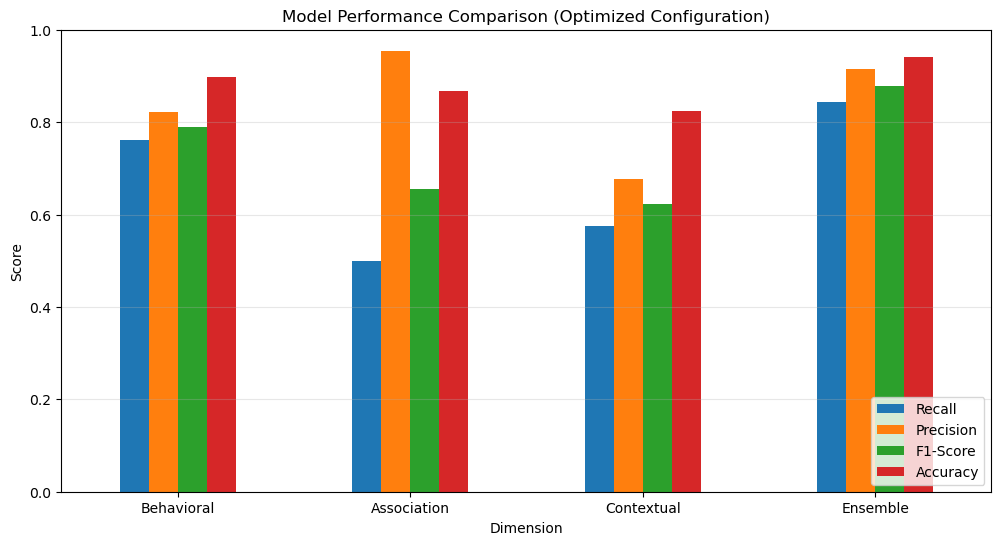

In [49]:
summary = pd.DataFrame({
    'Dimension': ['Behavioral', 'Association', 'Contextual', 'Ensemble'],
    'Model': ['XGBoost', 'GradientBoosting', 'XGBoost', 'Weighted Ensemble'],
    'Recall': [beh_recall, ass_recall, ctx_recall, ensemble_recall],
    'Precision': [beh_precision, ass_precision, ctx_precision, ensemble_precision],
    'F1-Score': [beh_f1, ass_f1, ctx_f1, ensemble_f1],
    'Accuracy': [beh_acc, ass_acc, ctx_acc, ensemble_acc],
    'ROC-AUC': [beh_auc, ass_auc, ctx_auc, ensemble_auc]
})

print("="*70)
print("TRAINING COMPLETE - PERFORMANCE SUMMARY (OPTIMIZED MODELS)")
print("="*70)
print("\n", summary.to_string(index=False))

print("\n" + "="*70)
print("OPTIMIZATION DETAILS")
print("="*70)
print(f"\nBehavioral Model: XGBoost")
print(f"  - Parameters optimized via GridSearchCV (Phase 2)")
print(f"  - n_estimators=150, max_depth=6, learning_rate=0.05")
print(f"  - Weight in ensemble: {normalized_weights['behavioral']:.2f}")

print(f"\nAssociation Model: Gradient Boosting")
print(f"  - Parameters optimized via GridSearchCV (Phase 2)")
print(f"  - n_estimators=150, max_depth=5, learning_rate=0.05")
print(f"  - Weight in ensemble: {normalized_weights['association']:.2f}")

print(f"\nContextual Model: XGBoost")
print(f"  - Parameters to be updated after optimization (Phase 2)")
print(f"  - n_estimators=150, max_depth=6, learning_rate=0.05 (placeholder)")
print(f"  - Weight in ensemble: {normalized_weights['contextual']:.2f}")

print(f"\nEnsemble Configuration:")
print(f"  - Weights optimized via grid search (Phase 3)")
print(f"  - Threshold optimized via grid search (Phase 4)")
print(f"  - Classification threshold: {CLASSIFICATION_THRESHOLD:.2f}")

# Visualize comparison
summary[['Dimension', 'Recall', 'Precision', 'F1-Score', 'Accuracy']].plot(
    x='Dimension', y=['Recall', 'Precision', 'F1-Score', 'Accuracy'], 
    kind='bar', figsize=(12, 6), title='Model Performance Comparison (Optimized Configuration)'
)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

## 14. Save Models

In [50]:
# Save models and scalers with optimized configurations
joblib.dump(behavioral_model, 'behavioral_xgboost_optimized.pkl')
joblib.dump(behavioral_scaler, 'behavioral_scaler_optimized.pkl')
print("Saved: behavioral_xgboost_optimized.pkl, behavioral_scaler_optimized.pkl")

joblib.dump(association_model, 'association_gradientboosting_optimized.pkl')
joblib.dump(association_scaler, 'association_scaler_optimized.pkl')
print("Saved: association_gradientboosting_optimized.pkl, association_scaler_optimized.pkl")

joblib.dump(contextual_model, 'contextual_xgboost_optimized.pkl')
joblib.dump(contextual_scaler, 'contextual_scaler_optimized.pkl')
print("Saved: contextual_xgboost_optimized.pkl, contextual_scaler_optimized.pkl")

# Save optimized ensemble configuration
ensemble_config = {
    'behavioral_model': 'XGBoost',
    'behavioral_params': {
        'n_estimators': 150,
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8
    },
    'association_model': 'GradientBoosting',
    'association_params': {
        'n_estimators': 150,
        'max_depth': 5,
        'learning_rate': 0.05,
        'subsample': 0.8
    },
    'contextual_model': 'XGBoost',
    'contextual_params': {
        'n_estimators': 150,
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8
    },
    'weights': normalized_weights,
    'threshold': CLASSIFICATION_THRESHOLD,
    'performance': {
        'behavioral': {
            'recall': float(beh_recall),
            'precision': float(beh_precision),
            'f1_score': float(beh_f1),
            'accuracy': float(beh_acc),
            'roc_auc': float(beh_auc)
        },
        'association': {
            'recall': float(ass_recall),
            'precision': float(ass_precision),
            'f1_score': float(ass_f1),
            'accuracy': float(ass_acc),
            'roc_auc': float(ass_auc)
        },
        'contextual': {
            'recall': float(ctx_recall),
            'precision': float(ctx_precision),
            'f1_score': float(ctx_f1),
            'accuracy': float(ctx_acc),
            'roc_auc': float(ctx_auc)
        },
        'ensemble': {
            'recall': float(ensemble_recall),
            'precision': float(ensemble_precision),
            'f1_score': float(ensemble_f1),
            'accuracy': float(ensemble_acc),
            'roc_auc': float(ensemble_auc)
        }
    }
}
joblib.dump(ensemble_config, 'ensemble_config_v1.pkl')
print("Saved: ensemble_config_v1.pkl")

# Save as JSON for readability
import json
with open('ensemble_config_v1.json', 'w') as f:
    json.dump(ensemble_config, f, indent=2)
print("Saved: ensemble_config_v1.json")

print("\n" + "="*70)
print("All optimized models and configurations saved successfully!")
print("="*70)

Saved: behavioral_xgboost_optimized.pkl, behavioral_scaler_optimized.pkl
Saved: association_gradientboosting_optimized.pkl, association_scaler_optimized.pkl
Saved: contextual_xgboost_optimized.pkl, contextual_scaler_optimized.pkl
Saved: ensemble_config_v1.pkl
Saved: ensemble_config_v1.json

All optimized models and configurations saved successfully!


## 15. Test Wallet Scoring Function

Example of how to score a new wallet

In [51]:
def score_wallet_with_shap(behavioral_features, association_features, contextual_features, include_shap=True, top_k=5):
    """
    Score a wallet using the trained ensemble with optional SHAP explanations
    
    Args:
        behavioral_features: Array/list of 9 behavioral features
        association_features: Array/list of 6 association features
        contextual_features: Array/list of 4 contextual features
        include_shap: Whether to compute SHAP explanations (default: True)
        top_k: Number of top contributing features to return (default: 5)
        
    Returns:
        Dict with risk score, dimension breakdown, and SHAP explanations
    """
    # Scale features
    beh_scaled = behavioral_scaler.transform([behavioral_features])
    ass_scaled = association_scaler.transform([association_features])
    ctx_scaled = contextual_scaler.transform([contextual_features])
    
    # Get dimension scores
    beh_score = behavioral_model.predict_proba(beh_scaled)[0, 1]
    ass_score = association_model.predict_proba(ass_scaled)[0, 1]
    ctx_score = contextual_model.predict_proba(ctx_scaled)[0, 1]
    
    # Calculate confidence scores from ensemble variance
    beh_confidence = calculate_confidence_score(behavioral_model, beh_scaled)[0]
    ass_confidence = calculate_confidence_score(association_model, ass_scaled)[0]
    ctx_confidence = calculate_confidence_score(contextual_model, ctx_scaled)[0]
    
    # Calculate dimension contributions
    beh_contribution = normalized_weights['behavioral'] * beh_score
    ass_contribution = normalized_weights['association'] * ass_score
    ctx_contribution = normalized_weights['contextual'] * ctx_score
    
    # Calculate weighted ensemble score
    final_score = beh_contribution + ass_contribution + ctx_contribution
    
    # Calculate weighted ensemble confidence
    ensemble_confidence = (
        normalized_weights['behavioral'] * beh_confidence +
        normalized_weights['association'] * ass_confidence +
        normalized_weights['contextual'] * ctx_confidence
    )
    
    # Make prediction
    prediction = 'HIGH RISK' if final_score >= CLASSIFICATION_THRESHOLD else 'LOW RISK'
    
    result = {
        'wallet_risk_score': float(final_score),
        'ensemble_confidence': float(ensemble_confidence),
        'prediction': prediction,
        'dimensions': {
            'behavioral': {
                'score': float(beh_score),
                'confidence': float(beh_confidence),
                'contribution': float(beh_contribution),
                'weight': float(normalized_weights['behavioral'])
            },
            'association': {
                'score': float(ass_score),
                'confidence': float(ass_confidence),
                'contribution': float(ass_contribution),
                'weight': float(normalized_weights['association'])
            },
            'contextual': {
                'score': float(ctx_score),
                'confidence': float(ctx_confidence),
                'contribution': float(ctx_contribution),
                'weight': float(normalized_weights['contextual'])
            }
        }
    }
    
    # Add SHAP explanations if requested
    if include_shap:
        result['shap_explanations'] = {}
        
        # Compute SHAP for Behavioral dimension if it contributes significantly
        if beh_contribution >= 0.3:
            shap_beh = explainer_behavioral.shap_values(beh_scaled)
            if isinstance(shap_beh, list):
                shap_beh = shap_beh[1]  # Class 1 (fraud)
            
            # Get top contributing features
            top_indices_beh = np.argsort(np.abs(shap_beh[0]))[-top_k:][::-1]
            
            result['shap_explanations']['behavioral'] = {
                'top_features': []
            }
            
            for idx in top_indices_beh:
                feature_name = BEHAVIORAL_FEATURES[idx]
                shap_value = float(shap_beh[0][idx])
                feature_value = float(beh_scaled[0][idx])
                direction = "increases" if shap_value > 0 else "decreases"
                
                result['shap_explanations']['behavioral']['top_features'].append({
                    'feature': feature_name,
                    'shap_value': shap_value,
                    'feature_value': feature_value,
                    'impact_direction': direction
                })
        
        # Compute SHAP for Association dimension if it contributes significantly
        if ass_contribution >= 0.3:
            shap_ass = explainer_association.shap_values(ass_scaled)
            if isinstance(shap_ass, list):
                shap_ass = shap_ass[1]  # Class 1 (fraud)
            
            # Get top contributing features
            top_indices_ass = np.argsort(np.abs(shap_ass[0]))[-top_k:][::-1]
            
            result['shap_explanations']['association'] = {
                'top_features': []
            }
            
            for idx in top_indices_ass:
                feature_name = ASSOCIATION_FEATURES[idx]
                shap_value = float(shap_ass[0][idx])
                feature_value = float(ass_scaled[0][idx])
                direction = "increases" if shap_value > 0 else "decreases"
                
                result['shap_explanations']['association']['top_features'].append({
                    'feature': feature_name,
                    'shap_value': shap_value,
                    'feature_value': feature_value,
                    'impact_direction': direction
                })
        
        # Compute SHAP for Contextual dimension if it contributes significantly
        if ctx_contribution >= 0.3:
            shap_ctx = explainer_contextual.shap_values(ctx_scaled)
            if isinstance(shap_ctx, list):
                shap_ctx = shap_ctx[1]  # Class 1 (fraud)
            
            # Get top contributing features
            top_indices_ctx = np.argsort(np.abs(shap_ctx[0]))[-top_k:][::-1]
            
            result['shap_explanations']['contextual'] = {
                'top_features': []
            }
            
            for idx in top_indices_ctx:
                feature_name = CONTEXTUAL_FEATURES[idx]
                shap_value = float(shap_ctx[0][idx])
                feature_value = float(ctx_scaled[0][idx])
                direction = "increases" if shap_value > 0 else "decreases"
                
                result['shap_explanations']['contextual']['top_features'].append({
                    'feature': feature_name,
                    'shap_value': shap_value,
                    'feature_value': feature_value,
                    'impact_direction': direction
                })
    
    return result

# Test on a sample high-risk wallet from test set
print("="*70)
print("WALLET SCORING WITH SHAP EXPLANATIONS")
print("="*70)

# Find a high-risk prediction for demo
high_risk_sample_idx = high_risk_indices[0] if len(high_risk_indices) > 0 else 0
sample_beh = X_beh_test.iloc[high_risk_sample_idx].values
sample_ass = X_ass_test.iloc[high_risk_sample_idx].values
sample_ctx = X_ctx_test.iloc[high_risk_sample_idx].values
actual_label = y_test.iloc[high_risk_sample_idx]

result = score_wallet_with_shap(sample_beh, sample_ass, sample_ctx, include_shap=True, top_k=5)

print(f"\nWallet Test Index: {high_risk_sample_idx}")
print(f"Actual Label: {'FRAUD' if actual_label == 1 else 'LEGITIMATE'}")
print("\n" + "-"*70)
print("RISK ASSESSMENT:")
print("-"*70)
print(f"Risk Score: {result['wallet_risk_score']:.4f}")
print(f"Confidence Level: {result['ensemble_confidence']:.1f}%")
print(f"Prediction: {result['prediction']}")

print("\n" + "-"*70)
print("DIMENSION CONTRIBUTIONS:")
print("-"*70)
print(f"Behavioral Dimension:")
print(f"  Score: {result['dimensions']['behavioral']['score']:.4f}")
print(f"  Confidence: {result['dimensions']['behavioral']['confidence']:.1f}%")
print(f"  Contribution: {result['dimensions']['behavioral']['contribution']:.4f}")
print(f"  Weight: {result['dimensions']['behavioral']['weight']:.2f}")

print(f"\nAssociation Dimension:")
print(f"  Score: {result['dimensions']['association']['score']:.4f}")
print(f"  Confidence: {result['dimensions']['association']['confidence']:.1f}%")
print(f"  Contribution: {result['dimensions']['association']['contribution']:.4f}")
print(f"  Weight: {result['dimensions']['association']['weight']:.2f}")

print(f"\nContextual Dimension:")
print(f"  Score: {result['dimensions']['contextual']['score']:.4f}")
print(f"  Confidence: {result['dimensions']['contextual']['confidence']:.1f}%")
print(f"  Contribution: {result['dimensions']['contextual']['contribution']:.4f}")
print(f"  Weight: {result['dimensions']['contextual']['weight']:.2f}")

# Display SHAP explanations
if 'shap_explanations' in result:
    print("\n" + "-"*70)
    print("SHAP FEATURE EXPLANATIONS:")
    print("-"*70)
    
    if 'behavioral' in result['shap_explanations']:
        print("\nBehavioral Dimension - Top Contributing Features:")
        for feat in result['shap_explanations']['behavioral']['top_features']:
            print(f"  • {feat['feature']}")
            print(f"    SHAP Value: {feat['shap_value']:+.4f} ({feat['impact_direction']} risk)")
            print(f"    Feature Value (scaled): {feat['feature_value']:.4f}")
    
    if 'association' in result['shap_explanations']:
        print("\nAssociation Dimension - Top Contributing Features:")
        for feat in result['shap_explanations']['association']['top_features']:
            print(f"  • {feat['feature']}")
            print(f"    SHAP Value: {feat['shap_value']:+.4f} ({feat['impact_direction']} risk)")
            print(f"    Feature Value (scaled): {feat['feature_value']:.4f}")
    
    if 'contextual' in result['shap_explanations']:
        print("\nContextual Dimension - Top Contributing Features:")
        for feat in result['shap_explanations']['contextual']['top_features']:
            print(f"  • {feat['feature']}")
            print(f"    SHAP Value: {feat['shap_value']:+.4f} ({feat['impact_direction']} risk)")
            print(f"    Feature Value (scaled): {feat['feature_value']:.4f}")

WALLET SCORING WITH SHAP EXPLANATIONS

Wallet Test Index: 14
Actual Label: FRAUD

----------------------------------------------------------------------
RISK ASSESSMENT:
----------------------------------------------------------------------
Risk Score: 0.8397
Confidence Level: 75.9%
Prediction: HIGH RISK

----------------------------------------------------------------------
DIMENSION CONTRIBUTIONS:
----------------------------------------------------------------------
Behavioral Dimension:
  Score: 0.9064
  Confidence: 73.8%
  Contribution: 0.3626
  Weight: 0.40

Association Dimension:
  Score: 0.9928
  Confidence: 70.7%
  Contribution: 0.4468
  Weight: 0.45

Contextual Dimension:
  Score: 0.2027
  Confidence: 97.0%
  Contribution: 0.0304
  Weight: 0.15

----------------------------------------------------------------------
SHAP FEATURE EXPLANATIONS:
----------------------------------------------------------------------

Behavioral Dimension - Top Contributing Features:
  • Sent tnx
 

In [52]:
# Test with a legitimate wallet (actual label = 0)
legitimate_indices = np.where(y_test.values == 0)[0]
legit_sample_idx = legitimate_indices[0] if len(legitimate_indices) > 0 else 0

sample_beh = X_beh_test.iloc[legit_sample_idx].values
sample_ass = X_ass_test.iloc[legit_sample_idx].values
sample_ctx = X_ctx_test.iloc[legit_sample_idx].values
actual_label = y_test.iloc[legit_sample_idx]

result = score_wallet_with_shap(sample_beh, sample_ass, sample_ctx, include_shap=True, top_k=5)

print(f"\nWallet Test Index: {legit_sample_idx}")
print(f"Actual Label: {'FRAUD' if actual_label == 1 else 'LEGITIMATE'}")
print("\n" + "-"*70)
print("RISK ASSESSMENT:")
print("-"*70)
print(f"Risk Score: {result['wallet_risk_score']:.4f}")
print(f"Confidence Level: {result['ensemble_confidence']:.1f}%")
print(f"Prediction: {result['prediction']}")

print("\n" + "-"*70)
print("DIMENSION CONTRIBUTIONS:")
print("-"*70)
print(f"Behavioral Dimension:")
print(f"  Score: {result['dimensions']['behavioral']['score']:.4f}")
print(f"  Confidence: {result['dimensions']['behavioral']['confidence']:.1f}%")
print(f"  Contribution: {result['dimensions']['behavioral']['contribution']:.4f}")
print(f"  Weight: {result['dimensions']['behavioral']['weight']:.2f}")

print(f"\nAssociation Dimension:")
print(f"  Score: {result['dimensions']['association']['score']:.4f}")
print(f"  Confidence: {result['dimensions']['association']['confidence']:.1f}%")
print(f"  Contribution: {result['dimensions']['association']['contribution']:.4f}")
print(f"  Weight: {result['dimensions']['association']['weight']:.2f}")

print(f"\nContextual Dimension:")
print(f"  Score: {result['dimensions']['contextual']['score']:.4f}")
print(f"  Confidence: {result['dimensions']['contextual']['confidence']:.1f}%")
print(f"  Contribution: {result['dimensions']['contextual']['contribution']:.4f}")
print(f"  Weight: {result['dimensions']['contextual']['weight']:.2f}")

# Display SHAP explanations
if 'shap_explanations' in result:
    print("\n" + "-"*70)
    print("SHAP FEATURE EXPLANATIONS:")
    print("-"*70)
    
    if 'behavioral' in result['shap_explanations']:
        print("\nBehavioral Dimension - Top Contributing Features:")
        for feat in result['shap_explanations']['behavioral']['top_features']:
            print(f"  • {feat['feature']}")
            print(f"    SHAP Value: {feat['shap_value']:+.4f} ({feat['impact_direction']} risk)")
            print(f"    Feature Value (scaled): {feat['feature_value']:.4f}")
    
    if 'association' in result['shap_explanations']:
        print("\nAssociation Dimension - Top Contributing Features:")
        for feat in result['shap_explanations']['association']['top_features']:
            print(f"  • {feat['feature']}")
            print(f"    SHAP Value: {feat['shap_value']:+.4f} ({feat['impact_direction']} risk)")
            print(f"    Feature Value (scaled): {feat['feature_value']:.4f}")
    
    if 'contextual' in result['shap_explanations']:
        print("\nContextual Dimension - Top Contributing Features:")
        for feat in result['shap_explanations']['contextual']['top_features']:
            print(f"  • {feat['feature']}")
            print(f"    SHAP Value: {feat['shap_value']:+.4f} ({feat['impact_direction']} risk)")
            print(f"    Feature Value (scaled): {feat['feature_value']:.4f}")



Wallet Test Index: 0
Actual Label: LEGITIMATE

----------------------------------------------------------------------
RISK ASSESSMENT:
----------------------------------------------------------------------
Risk Score: 0.2424
Confidence Level: 91.5%
Prediction: LOW RISK

----------------------------------------------------------------------
DIMENSION CONTRIBUTIONS:
----------------------------------------------------------------------
Behavioral Dimension:
  Score: 0.3137
  Confidence: 85.2%
  Contribution: 0.1255
  Weight: 0.40

Association Dimension:
  Score: 0.2100
  Confidence: 95.8%
  Contribution: 0.0945
  Weight: 0.45

Contextual Dimension:
  Score: 0.1497
  Confidence: 95.0%
  Contribution: 0.0225
  Weight: 0.15

----------------------------------------------------------------------
SHAP FEATURE EXPLANATIONS:
----------------------------------------------------------------------
